# `nicheDE` (R) ⇄ `pynichede` (Python) — function-by-function dictionary

**Notebook 3 of 4.** Audience: **an R user porting an existing `nicheDE` script to Python.**

Notebook 1 compares the *pipeline*; Notebook 2 teaches the *Python API*. This notebook is the
**translation table**: one subsection per exported R symbol, each with

* a one-paragraph description of what the function does,
* a **full parameter table** — every R parameter gets a row, including ones that are renamed,
  computed internally, or no-ops in Python; parameters that exist only in Python are marked
  **new in Python** with the rationale,
* the **R one-liner** you would have written (markdown only — R is executed once, up front, by
  `examples/r_per_function_dump.R` and `tests/r_reference_driver.R`),
* the **Python equivalent**, executed,
* a **numerical comparison** against the R dump, and
* a **sub-verdict**.

The scope is the 26 symbols in
[`nichede-ref/NAMESPACE`](https://github.com/kaishumason/NicheDE/blob/87e0e89/NAMESPACE):
25 `export()` entries plus `S3method(print, Niche_DE)`.

### Base-index warning, up front

Three functions take **cell-type positions** rather than names. R's are **1-based**, Python's
are **0-based**:

| function | R | Python |
|---|---|---|
| `contrast_post` | `index`, `niche` are `1..n_type` | `index`, `niche` are `0..n_type-1` |
| `check_colloc` | `index`, `niche` are `1..n_type` | `index`, `niche` are `0..n_type-1` |
| `nulls` inside `obj@niche_DE[[k]][[g]]` | `1..n_type^2` | `0..n_type^2-1` |

A literal transcription of an R script therefore shifts every cell type by one. The class API
(`NicheDE.check_colloc(index_name, niche_name)`) takes names and sidesteps it entirely.

## 1. Intro + setup

In [1]:
%matplotlib inline
import os, sys, json, re, time, subprocess, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

PKG_ROOT = os.environ.get("PYNICHEDE_ROOT",
                          "/scratch/users/steorra/analysis/omicverse_dev/py-nichede")
REF_DIR  = os.environ.get("NICHEDE_REF_DIR",     "/scratch/users/steorra/nichede_ref_out/full")
DEV_DIR  = os.environ.get("NICHEDE_DEV_REF_DIR", "/scratch/users/steorra/nichede_ref_out/dev300")
PERFUNC  = os.environ.get("NICHEDE_PERFUNC_DIR", "/scratch/users/steorra/nichede_ref_out/perfunc")
RSCRIPT  = os.environ.get("NICHEDE_RSCRIPT",     "/scratch/users/steorra/env/CMAP/bin/Rscript")
R_LIBS   = os.environ.get("NICHEDE_R_LIBS",      "/scratch/users/steorra/Rlibs_nichede")
N_JOBS   = int(os.environ.get("NICHEDE_N_JOBS", "16"))

os.environ.setdefault("TMPDIR", "/scratch/users/steorra/tmp")
os.environ.setdefault("JOBLIB_TEMP_FOLDER", os.environ["TMPDIR"])
os.makedirs(os.environ["TMPDIR"], exist_ok=True)
for _p in (PKG_ROOT, os.path.join(PKG_ROOT, "tests")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from refload import RefDump                      # tests/refload.py
from parity_report import det, corr, infer       # tests/parity_report.py
import pynichede as nde

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False, "figure.autolayout": True})
C_R, C_PY, C_BAD = "#1f4e79", "#c1440e", "#8b0000"

def sub(a, n=20000, seed=0):
    """Deterministic subsample of a flat array, for readable scatter plots."""
    a = np.asarray(a).ravel()
    if a.size <= n:
        return np.arange(a.size)
    return np.sort(np.random.default_rng(seed).choice(a.size, n, replace=False))

def overlay_det(ref, cand, title, unit="", ax=None):
    """`deterministic` visual: sorted R vs Py overlay + the max abs error."""
    r = np.asarray(ref, dtype=float).ravel()
    c = np.asarray(cand, dtype=float).ravel()
    m = np.isfinite(r) & np.isfinite(c)
    o = np.argsort(r[m], kind="stable")
    err = float(np.max(np.abs(r[m] - c[m]))) if m.any() else 0.0
    if ax is None:
        fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.1))
    i = sub(r[m][o], 8000)
    ax[0].plot(np.arange(i.size), r[m][o][i], color=C_R, lw=2.2, label="R (nicheDE)")
    ax[0].plot(np.arange(i.size), c[m][o][i], color=C_PY, lw=0.9, ls="--",
               label="Python (pynichede)")
    ax[0].set_xlabel("entry (sorted by the R value)")
    ax[0].set_ylabel(unit or "value")
    ax[0].set_title(f"{title} — overlay")
    ax[0].legend(loc="upper left")
    d = np.abs(r[m] - c[m])
    d = d[d > 0]
    if d.size:
        ax[1].hist(np.log10(d), bins=50, color=C_PY, alpha=0.85)
        ax[1].set_xlabel("log10 |R - Python|")
    else:
        ax[1].text(0.5, 0.5, "bit-identical\n(all differences exactly 0)",
                   ha="center", va="center", transform=ax[1].transAxes)
        ax[1].set_xticks([])
    ax[1].set_ylabel("count")
    ax[1].set_title(f"max |err| = {err:.3e}   (n = {int(m.sum())})")
    return err

def scatter_corr(ref, cand, title, ax=None, label="T_stat"):
    """`pearson` / ordinal visual: R vs Py scatter with Pearson + Spearman."""
    st = corr(ref, cand)
    r = np.asarray(ref, dtype=float).ravel()
    c = np.asarray(cand, dtype=float).ravel()
    m = np.isfinite(r) & np.isfinite(c)
    i = sub(r[m], 25000)
    if ax is None:
        fig, ax = plt.subplots(figsize=(4.0, 3.8))
    ax.scatter(r[m][i], c[m][i], s=3, alpha=0.25, color=C_PY, edgecolors="none")
    lo, hi = float(np.min(r[m])), float(np.max(r[m]))
    ax.plot([lo, hi], [lo, hi], color=C_R, lw=1.0, ls="--", label="y = x")
    ax.set_xlabel(f"R {label}")
    ax.set_ylabel(f"Python {label}")
    ax.set_title(f"{title}\nPearson {st['pearson']:.6f} | Spearman {st['spearman']:.6f}\n"
                 f"n = {st['n']}, max|err| = {st['max_abs_err']:.2e}", fontsize=8)
    ax.legend(loc="upper left", fontsize=7)
    return st

def scatter_pval(ref, cand, title, axes=None, ks=(10, 25, 50, 100, 250, 500)):
    """`inference` visual: -log10(p) scatter + top-K overlap curve."""
    st = infer(ref, cand)
    r = np.clip(np.asarray(ref, dtype=float).ravel(), 1e-300, 1.0)
    c = np.clip(np.asarray(cand, dtype=float).ravel(), 1e-300, 1.0)
    m = np.isfinite(r) & np.isfinite(c)
    r, c = r[m], c[m]
    if axes is None:
        fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.3))
    i = sub(r, 25000)
    axes[0].scatter(-np.log10(r[i]), -np.log10(c[i]), s=3, alpha=0.25,
                    color=C_PY, edgecolors="none")
    hi = float(np.max(-np.log10(r))) if r.size else 1.0
    axes[0].plot([0, hi], [0, hi], color=C_R, lw=1.0, ls="--")
    axes[0].set_xlabel("R  -log10(p)")
    axes[0].set_ylabel("Python  -log10(p)")
    axes[0].set_title(f"{title}\nSpearman(-log10 p) = {st['spearman_neglog10p']:.6f}"
                      f"  (n = {st['n']})", fontsize=8)
    jac, kk = [], []
    for k in ks:
        k = min(k, r.size)
        a = set(np.argsort(r, kind="stable")[:k].tolist())
        b = set(np.argsort(c, kind="stable")[:k].tolist())
        jac.append(len(a & b) / len(a | b))
        kk.append(k)
    axes[1].plot(kk, jac, "o-", color=C_PY)
    axes[1].axhline(0.70, color=C_BAD, ls="--", lw=1, label="gate 0.70")
    axes[1].set_xscale("log")
    axes[1].set_ylim(0, 1.05)
    axes[1].set_xlabel("K (most significant genes)")
    axes[1].set_ylabel("top-K Jaccard(R, Python)")
    axes[1].set_title(f"top-50 Jaccard = {st['top50_jaccard']:.3f}", fontsize=8)
    axes[1].legend(fontsize=7)
    return st

print("pynichede", nde.__version__, "| python", sys.version.split()[0],
      "| numpy", np.__version__, "| scipy", __import__("scipy").__version__)
print("REF_DIR    ", REF_DIR)
print("PERFUNC_DIR", PERFUNC)

pynichede 0.1.0 | python 3.10.20 | numpy 2.2.6 | scipy 1.15.3
REF_DIR     /scratch/users/steorra/nichede_ref_out/full
PERFUNC_DIR /scratch/users/steorra/nichede_ref_out/perfunc


### 1.1 Run the R per-function driver

`examples/r_per_function_dump.R` dumps everything the pipeline driver does **not** already
carry: the `print.Niche_DE` string, direct `gene_level_fisher` / `celltype_level_fisher`
probes, the two Seurat constructors, and version metadata. It deliberately re-uses
`tests/r_reference_driver.R`'s dump for every function that is already covered there (and skips
re-dumping the 78 MB NicheNet matrix, which `tests/r_reference_supplement.R` already wrote), so
it runs in well under a minute.

In [2]:
os.makedirs(PERFUNC, exist_ok=True)
driver = os.path.join(PKG_ROOT, "examples", "r_per_function_dump.R")
cmd = [RSCRIPT,
       "-e", '.libPaths(c(Sys.getenv("R_LIBS_USER"), .libPaths())); '
             'source(commandArgs(trailingOnly = TRUE)[3])',
       PERFUNC, REF_DIR, driver]
print("$", " ".join(cmd))
t0 = time.perf_counter()
res = subprocess.run(cmd, capture_output=True, text=True,
                     env=dict(os.environ, R_LIBS_USER=R_LIBS),
                     cwd=os.path.join(PKG_ROOT, "examples"))
print(res.stdout[-1500:])
if res.returncode != 0:
    print("STDERR:", res.stderr[-2000:])
print(f"exit {res.returncode}  in {time.perf_counter() - t0:.1f} s")
assert res.returncode == 0 and "DONE ->" in res.stdout

$ /scratch/users/steorra/env/CMAP/bin/Rscript -e .libPaths(c(Sys.getenv("R_LIBS_USER"), .libPaths())); source(commandArgs(trailingOnly = TRUE)[3]) /scratch/users/steorra/nichede_ref_out/perfunc /scratch/users/steorra/nichede_ref_out/full /scratch/users/steorra/analysis/omicverse_dev/py-nichede/examples/r_per_function_dump.R


[1] "Creating Niche-DE object"
[1] "Niche-DE object created with 848 observations, 21708 genes, 1 batch(es), and 7 cell types."
[1] "Calculating effective niche for kernel bandwith 1(1 out of 3 values)."
[1] "Calculating effective niche for kernel bandwith 100(2 out of 3 values)."
[1] "Calculating effective niche for kernel bandwith 250(3 out of 3 values)."
[1] "Effective niche calculated"
[1] "Computing average expression profile matrix"
[1] "Average expression profile matrix computed."
[1] "Creating Niche-DE object"
[1] "Niche-DE object created with 848 observations, 21708 genes, 1 batch(es), and 7 cell types."
DONE -> /scratch/users/steorra/nichede_ref_out/perfunc 

exit 0  in 6.5 s


In [3]:
pf = RefDump(PERFUNC)
print("R stack the reference was produced with")
for k in ["R_version", "platform", "nicheDE_version", "poolr_version",
          "Rfast_version", "Seurat_version", "Matrix_version"]:
    print(f"  {k:18s} {pf.meta[k]}")
print("\nSeurat constructors reproduced:", pf.meta["seurat_ok"])
print("NicheNet matrix reused from the pipeline dump:", pf.meta["ltm_from_pipeline_dump"])

R stack the reference was produced with
  R_version          R version 4.4.3 (2025-02-28)
  platform           x86_64-conda-linux-gnu
  nicheDE_version    0.0.0.9000
  poolr_version      1.2.0
  Rfast_version      2.1.5.2
  Seurat_version     5.4.0
  Matrix_version     1.7.5

Seurat constructors reproduced: True
NicheNet matrix reused from the pipeline dump: True


### 1.2 Load the canonical fixture

In [4]:
d = RefDump(REF_DIR)
cts    = list(d.meta["cell_types"])
cells  = list(d.meta["cell_names"])
genes  = list(d.meta["gene_names"])
sigma  = np.atleast_1d(np.asarray(d.meta["sigma"], dtype=float))

counts = pd.DataFrame(d["ref_counts"],   index=cells, columns=genes)
coord  = pd.DataFrame(d["in_coord"],     index=cells, columns=["imagerow", "imagecol"])
libmat = pd.DataFrame(d["ref_ref_expr"], index=cts,   columns=genes)
deconv = pd.DataFrame(d["in_deconv"],    index=cells, columns=cts)

print(f"counts  {counts.shape}  (spots x genes)")
print(f"coord   {coord.shape}")
print(f"libmat  {libmat.shape}  (cell types x genes)")
print(f"deconv  {deconv.shape}")
print("cell types:", cts)
print("kernel bandwidths (sigma):", sigma)

counts  (848, 21708)  (spots x genes)
coord   (848, 2)
libmat  (7, 21708)  (cell types x genes)
deconv  (848, 7)
cell types: ['hepatocytes+cholangiocytes', 'T', 'B_plasma', 'tumor_epithelial', 'endothelial', 'myeloid', 'stromal']
kernel bandwidths (sigma): [  1. 100. 250.]


### 1.3 Verdict accumulator

Every subsection appends one row per compared output. The aggregate table is rendered in
section 3.

In [5]:
VERDICTS = []

def verdict(fn, output, cls, metric, value, ok):
    """Record one function x output comparison. `ok=None` marks a documented divergence."""
    if ok is None:
        mark, txt = "⚠️", "documented"
    elif ok:
        mark, txt = "✅", "PASS"
    else:
        mark, txt = "❌", "FAIL"
    VERDICTS.append(dict(Function=fn, Output=output, Class=cls, Metric=metric,
                         Value=f"{value:.6g}", Pass=f"{mark} {txt}", ok=ok))
    display(Markdown(f"**Sub-verdict — `{fn}` / {output}: {mark} {metric} = {value:.6g} "
                     f"({txt})**"))
print("verdict() ready")

verdict() ready


## 2. One subsection per exported R function

26 symbols, in the order they appear in the R sources
(`niche_DE_object_creation.R` → `niche_DE_main_functions.R` → `niche_DE_helper_functions.R`).

### 2.1 `print.Niche_DE` → `NicheDEObject.__repr__`

The S3 print method for the `Niche_DE` S4 class. Registered with `S3method(print, Niche_DE)` rather than `export()`, so it is reached through `print(obj)` (or `getS3method`). It returns — rather than cats — a one-line summary string. In Python the same string is produced by `NicheDEObject.__repr__`, so `print(obj)` and `repr(obj)` both work and `NicheDE.__repr__` forwards to it.

**Parameters**

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `object` | `self` | Niche_DE / NicheDEObject | — | a constructed object | the object to summarise |

**R**

```r
print(obj)   # dispatches to nicheDE:::print.Niche_DE
```

**Python**

In [6]:
# print.Niche_DE needs an object, so build one here; section 2.4 grades the
# constructor itself and rebuilds `obj` with the identical call.
obj = nde.create_nichede_object(counts, coord, libmat, deconv, sigma=sigma, Int=True)
r_str = pf.meta["ref_print_Niche_DE"]
py_str = repr(obj)
print("R      :", r_str)
print("Python :", py_str)
ok = (r_str == py_str)
print("identical string:", ok)
verdict("print.Niche_DE", "summary string", "deterministic", "exact string match",
        1.0 if ok else 0.0, ok)

R      : Niche-DE object with 848 observations, 21708 genes, 1 batch(es), and 7 cell types.
Python : Niche-DE object with 848 observations, 21708 genes, 1 batch(es), and 7 cell types.
identical string: True


**Sub-verdict — `print.Niche_DE` / summary string: ✅ exact string match = 1 (PASS)**

### 2.2 `CreateLibraryMatrix` → `pynichede.create_library_matrix`

Average expression profile per cell type: for each level of `cell_type[, 2]` it takes the column means of the corresponding rows of `data`, downsampling to 1000 cells first if the type is larger. Row order follows R's `unique()`, i.e. **first appearance**, not sorted.

**Parameters**

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `data` | `data` | matrix / dgCMatrix / DataFrame | — | cells × genes | single-cell (or spot) counts. Python also accepts a `scipy.sparse` matrix or a `pandas.DataFrame`; row names must be present because both languages check them. |
| `cell_type` | `cell_type` | data.frame / DataFrame or 2-col array | — | column 1 = cell name, column 2 = cell type | assignment table; column 1 must line up **row for row** with `data`. |
| — | `random_state` | int or None | `None` | any seed | **new in Python.** R calls bare `sample()` for the >1000-cell downsampling, so its result depends on the ambient `.Random.seed`; the Python argument makes that reproducible. Not reached on this fixture (no cell type exceeds 1000). |

**R**

```r
L <- nicheDE::CreateLibraryMatrix(data, cell_type)
```

**Python**

R rownames : ['ct2', 'ct3', 'ct4', 'ct1']
Py index   : ['ct2', 'ct3', 'ct4', 'ct1']


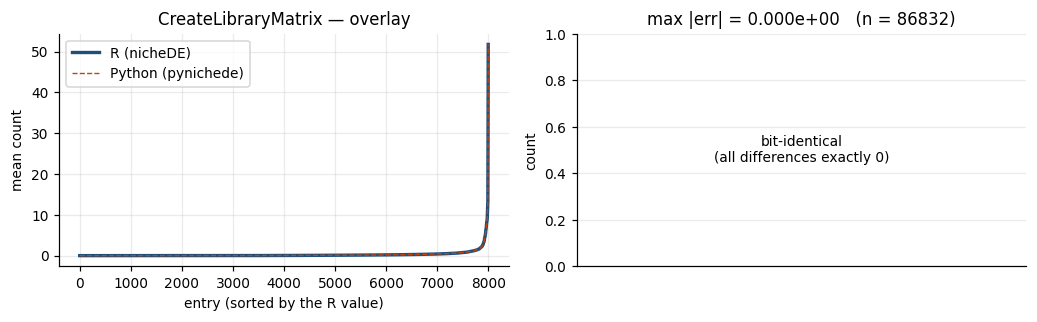

**Sub-verdict — `CreateLibraryMatrix` / library matrix: ✅ max abs err = 0 (PASS)**

In [7]:
ct_df = pd.DataFrame({"cell": cells, "type": list(d.meta["probe_ct_labels"])})
L_py = nde.create_library_matrix(counts, ct_df)
L_R  = d["ref_CreateLibraryMatrix"]
print("R rownames :", list(d.meta["probe_ct_types"]))
print("Py index   :", list(L_py.index))
e = det(L_R, L_py.to_numpy())["max_abs_err"]
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.0))
overlay_det(L_R, L_py.to_numpy(), "CreateLibraryMatrix", "mean count", ax); plt.show()
verdict("CreateLibraryMatrix", "library matrix", "deterministic", "max abs err", e, e <= 1e-8)

### 2.3 `CreateLibraryMatrixFromSeurat` → `pynichede.create_library_matrix_from_anndata`

The Seurat front end of `CreateLibraryMatrix`: it pulls `GetAssay(obj, assay)@counts`, transposes it to cells × genes, and takes the cell-type labels from `Idents(obj)`. The Python port takes an **AnnData** instead, because that is the equivalent Python object model — `Idents(obj)` maps to `adata.obs[celltype_key]` and the counts slot to `adata.layers[layer]` or `adata.X`. Note the R function reads the v3-only slot `sobj_assay@counts` and therefore **fails on Seurat ≥ 5 `Assay5` objects**; the reference below was produced with `options(Seurat.object.assay.version = 'v3')`.

**Parameters**

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `seurat_object` | `adata` | Seurat / AnnData | — | — | **type changed.** Seurat object → `anndata.AnnData`. |
| `assay` | `layer` | character / str or None | — | an assay / layer name | **renamed + semantics.** R selects a Seurat assay; Python selects `adata.layers[layer]`, or `adata.X` when `layer=None`. |
| — | `celltype_key` | str | — | a column of `adata.obs` | **new in Python.** Replaces `Seurat::Idents(obj)`, which has no AnnData analogue — AnnData has no privileged identity column, so it must be named. |
| — | `random_state` | int or None | `None` | any seed | **new in Python.** Same downsampling seed as `create_library_matrix`. |

**R**

```r
L <- nicheDE::CreateLibraryMatrixFromSeurat(seurat_object, assay = "RNA")
```

**Python**

R (Seurat) : (4, 400) ['ct2', 'ct3', 'ct4', 'ct1']
Py(AnnData): (4, 400) ['ct2', 'ct3', 'ct4', 'ct1']
Seurat build note: built with options(Seurat.object.assay.version = 'v3'); the shipped nicheDE code reads sobj_assay@counts and fails on Seurat 5 Assay5 objects


/scratch/users/steorra/tmp/ipykernel_19509/446308997.py:7: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  A.obs["cell_type"] = pd.Categorical(labels, categories=pd.unique(labels))


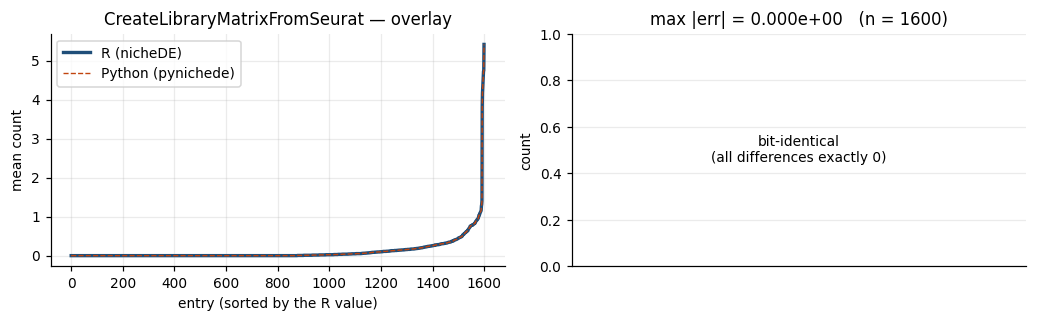

**Sub-verdict — `CreateLibraryMatrixFromSeurat` / library matrix: ✅ max abs err = 0 (PASS)**

In [8]:
import anndata as ad
sub_genes = list(pf.meta["seurat_sub_genes"])
labels    = list(pf.meta["seurat_ct_labels"])
counts_pre = pd.DataFrame(d["in_counts"], index=cells, columns=list(pf.meta["counts_genes"]))
A = ad.AnnData(counts_pre[sub_genes].to_numpy())
A.obs_names = cells; A.var_names = sub_genes
A.obs["cell_type"] = pd.Categorical(labels, categories=pd.unique(labels))
L_seu_py = nde.create_library_matrix_from_anndata(A, "cell_type")
L_seu_R  = pf["ref_CreateLibraryMatrixFromSeurat"]
print("R (Seurat) :", L_seu_R.shape, list(pf.meta["seurat_lib_types"]))
print("Py(AnnData):", tuple(L_seu_py.shape), list(L_seu_py.index))
print("Seurat build note:", pf.meta["seurat_note"])
e = det(L_seu_R, L_seu_py.to_numpy())["max_abs_err"]
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.0))
overlay_det(L_seu_R, L_seu_py.to_numpy(), "CreateLibraryMatrixFromSeurat", "mean count", ax)
plt.show()
verdict("CreateLibraryMatrixFromSeurat", "library matrix", "deterministic",
        "max abs err", e, e <= 1e-8)

### 2.4 `CreateNicheDEObject` → `pynichede.create_nichede_object`

Builds the `Niche_DE` object: intersects the genes of the counts and library matrices (keeping the **library matrix's** ordering), converts deconvolution weights into expected cell counts per spot, and rescales the coordinates so the mean second-nearest-neighbour spot distance is 100 — which is why `sigma` is in those rescaled units.

**Parameters**

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `counts_mat` | `counts_mat` | matrix / DataFrame | — | spots × genes | raw spatial counts; row and column names required and must be unique. |
| `coordinate_mat` | `coordinate_mat` | matrix / DataFrame | — | spots × 2 | spot coordinates; rescaled internally, `obj@scale` records the factor. |
| `library_mat` | `library_mat` | matrix / DataFrame | — | cell types × genes | reference average expression profile per cell type. |
| `deconv_mat` | `deconv_mat` | matrix / DataFrame | — | spots × cell types | deconvolution weights; column names must equal `rownames(library_mat)`. |
| `sigma` | `sigma` | numeric vector / sequence | — (required in R) | positive | **default changed.** R has no default and errors if missing; Python defaults to `()`, which triggers the same fallback R uses internally, `[0.1*d, d, 2*d, 3*d]` with `d` = the rescaled spot distance. |
| `Int` | `Int` | logical / bool | `TRUE` / `True` | — | `True` → counts must be integers, negative-binomial branch downstream; `False` → linear model with a gene-specific variance. |
| — | `random_state` | int or None | `None` | any seed | **new in Python.** Only reached for > 10 000 spots, where R subsamples 1000 points to estimate the spot distance. |

**R**

```r
obj <- nicheDE::CreateNicheDEObject(counts_mat, coordinate_mat, library_mat,
                                    deconv_mat, sigma = c(1, 100, 250), Int = TRUE)
```

**Python**

  num_cells              max abs err = 4.741e-14
  coord (rescaled)       max abs err = 0.000e+00
  ref_expr               max abs err = 0.000e+00
  counts (reordered)     max abs err = 0.000e+00
  scale                  max abs err = 0.000e+00
gene order identical to R: True


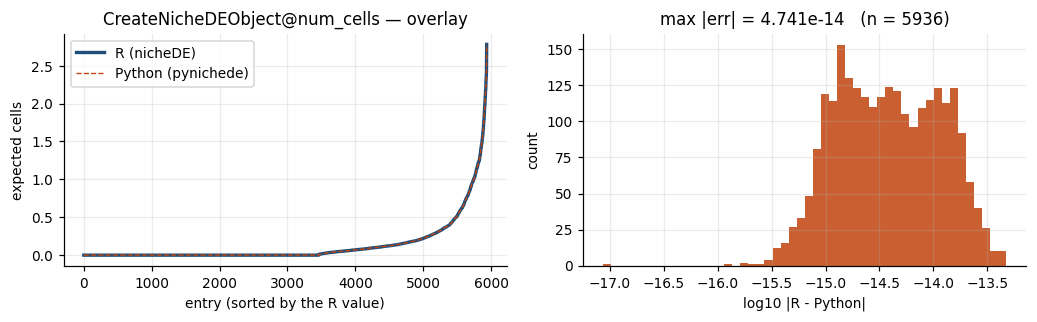

**Sub-verdict — `CreateNicheDEObject` / num_cells / coord / ref_expr / counts: ✅ max abs err = 4.74065e-14 (PASS)**

In [9]:
obj = nde.create_nichede_object(counts, coord, libmat, deconv, sigma=sigma, Int=True)
rows = {
    "num_cells": det(d["ref_num_cells"], np.asarray(obj.num_cells))["max_abs_err"],
    "coord (rescaled)": det(d["ref_coord"], np.asarray(obj.coord))["max_abs_err"],
    "ref_expr": det(d["ref_ref_expr"], np.asarray(obj.ref_expr))["max_abs_err"],
    "counts (reordered)": det(d["ref_counts"], np.asarray(obj.counts))["max_abs_err"],
    "scale": abs(float(np.atleast_1d(d.meta["ref_scale"])[0]) - float(obj.scale[0])),
}
for k, v in rows.items():
    print(f"  {k:22s} max abs err = {v:.3e}")
print("gene order identical to R:", list(obj.gene_names) == list(d.meta["gene_names"]))
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.0))
overlay_det(d["ref_num_cells"], np.asarray(obj.num_cells),
            "CreateNicheDEObject@num_cells", "expected cells", ax)
plt.show()
e = max(rows.values())
verdict("CreateNicheDEObject", "num_cells / coord / ref_expr / counts", "deterministic",
        "max abs err", e, e <= 1e-8)

### 2.5 `CreateNicheDEObjectFromSeurat` → `pynichede.create_nichede_object_from_anndata`

Same constructor, Seurat front end: counts from `GetAssay(obj, assay)@counts` and coordinates from `seurat_object@images[[1]]@coordinates$imagerow / $imagecol`. The Python port reads `adata.X` (or a layer) and `adata.obsm[spatial_key]`, then delegates to `create_nichede_object`, so everything after the extraction step is shared code.

**Parameters**

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `seurat_object` | `adata` | Seurat / AnnData | — | — | **type changed**, as for `CreateLibraryMatrixFromSeurat`. |
| `assay` | `layer` | character / str or None | — | assay / layer name | **renamed + semantics**; `None` means `adata.X`. |
| `library_mat` | `library_mat` | matrix / DataFrame | — | cell types × genes | as above. |
| `deconv_mat` | `deconv_mat` | matrix / DataFrame | — | spots × cell types | as above. |
| `sigma` | `sigma` | numeric vector / sequence | — / `()` | positive | **default changed**, as for `CreateNicheDEObject`. |
| `Int` | `Int` | logical / bool | `TRUE` / `True` | — | as above. |
| — | `spatial_key` | str | `'spatial'` | a key of `adata.obsm` | **new in Python.** Replaces R's hard-coded `@images[[1]]@coordinates`; AnnData stores coordinates under a user-chosen `obsm` key. |
| — | `random_state` | int or None | `None` | any seed | as above. |

**R**

```r
obj <- nicheDE::CreateNicheDEObjectFromSeurat(seurat_object, "Spatial",
                                              library_mat, deconv_mat, sigma, Int = TRUE)
```

**Python**

num_cells  max abs err vs R(Seurat) = 4.741e-14
coord      max abs err vs R(Seurat) = 0.000e+00
scale  R = 0.241259437319412  Python = 0.241259437319412


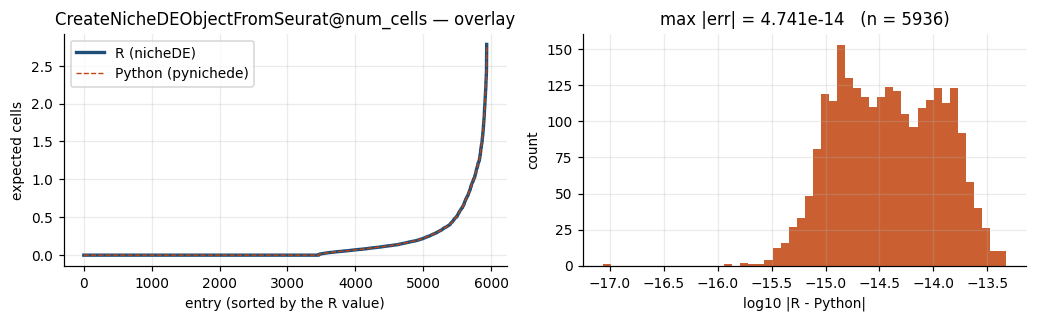

**Sub-verdict — `CreateNicheDEObjectFromSeurat` / num_cells / coord: ✅ max abs err = 4.74065e-14 (PASS)**

In [10]:
A2 = ad.AnnData(np.asarray(counts, dtype=np.float64))
A2.obs_names = cells; A2.var_names = genes
A2.obsm["spatial"] = np.asarray(coord, dtype=np.float64)
obj_seu = nde.create_nichede_object_from_anndata(A2, libmat, deconv, sigma=sigma,
                                                 spatial_key="spatial", Int=True)
e_nc = det(pf["ref_seurat_num_cells"], np.asarray(obj_seu.num_cells))["max_abs_err"]
e_co = det(pf["ref_seurat_coord"], np.asarray(obj_seu.coord))["max_abs_err"]
print(f"num_cells  max abs err vs R(Seurat) = {e_nc:.3e}")
print(f"coord      max abs err vs R(Seurat) = {e_co:.3e}")
print("scale  R =", float(np.atleast_1d(pf.meta["ref_seurat_scale"])[0]),
      " Python =", float(obj_seu.scale[0]))
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.0))
overlay_det(pf["ref_seurat_num_cells"], np.asarray(obj_seu.num_cells),
            "CreateNicheDEObjectFromSeurat@num_cells", "expected cells", ax)
plt.show()
e = max(e_nc, e_co)
verdict("CreateNicheDEObjectFromSeurat", "num_cells / coord", "deterministic",
        "max abs err", e, e <= 1e-8)
del A2, obj_seu

### 2.6 `MergeObjects` → `pynichede.merge_objects`

Concatenates several objects into one, dividing each subsequent object's coordinates by `(100/scale_j)/(100/scale_1)` so one kernel bandwidth means the same physical distance in every batch, and assigning `batch_ID`. Validates that all objects share kernel bandwidths, `Int`, reference expression, cell types and gene order.

**Parameters**

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `objects` | `objects` | list of Niche_DE / list[NicheDEObject] | — | length ≥ 1 | the objects to merge; the first one defines the coordinate scale and gene order. Python also accepts a tuple, and `NicheDE.merge` accepts wrapped class instances. |

**R**

```r
om <- nicheDE::MergeObjects(list(o1, o2))
```

**Python**

coord      max abs err = 0.000e+00
num_cells  max abs err = 4.741e-14
batch_ID   max abs err = 0.000e+00
R merge scale: [1, 2]  Python: [np.float64(1.0), np.float64(2.0)]


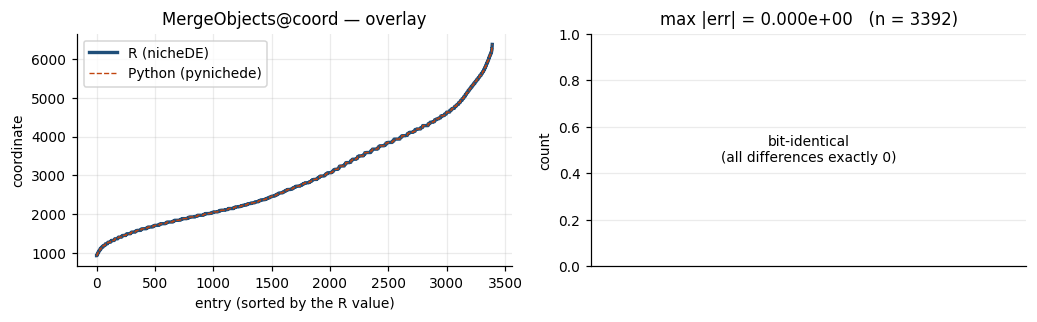

**Sub-verdict — `MergeObjects` / coord / num_cells / batch_ID: ✅ max abs err = 4.74065e-14 (PASS)**

In [11]:
o1 = nde.create_nichede_object(counts, coord, libmat, deconv, sigma=sigma, Int=True)
o2 = nde.create_nichede_object(counts, coord * 2, libmat, deconv, sigma=sigma, Int=True)
om = nde.merge_objects([o1, o2])
e_c = det(d["ref_merge_coord"], np.asarray(om.coord))["max_abs_err"]
e_n = det(d["ref_merge_num_cells"], np.asarray(om.num_cells))["max_abs_err"]
e_b = det(d["ref_merge_batch"], np.asarray(om.batch_ID))["max_abs_err"]
print(f"coord      max abs err = {e_c:.3e}")
print(f"num_cells  max abs err = {e_n:.3e}")
print(f"batch_ID   max abs err = {e_b:.3e}")
print("R merge scale:", d.meta["merge_scale"], " Python:", list(om.scale))
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.0))
overlay_det(d["ref_merge_coord"], np.asarray(om.coord), "MergeObjects@coord", "coordinate", ax)
plt.show()
e = max(e_c, e_n, e_b)
verdict("MergeObjects", "coord / num_cells / batch_ID", "deterministic",
        "max abs err", e, e <= 1e-8)
del o1, o2, om

### 2.7 `Filter_NDE` → `pynichede.filter_nde`

Subsets an object to the named observations. Because R implements it as a membership test (`obj@cell_names %in% cell_names`) the surviving rows keep their **original** order rather than the order of `cell_names`; the port reproduces that.

**Parameters**

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `object` | `obj` | Niche_DE / NicheDEObject | — | — | the object to subset. |
| `cell_names` | `cell_names` | character vector / sequence[str] | — | subset of `obj@cell_names` | names to keep; both languages error if any name is absent. |

**R**

```r
of <- nicheDE::Filter_NDE(obj, keep_cells)
```

**Python**

kept 283 of 848 spots (R kept 283)
num_cells        max abs err = 4.741e-14
effective_niche  max abs err = 1.679e-13
row order preserved: True


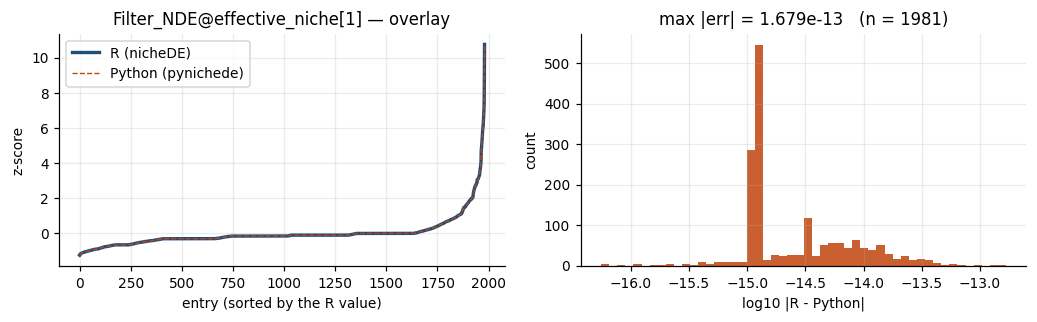

**Sub-verdict — `Filter_NDE` / num_cells / effective_niche: ✅ max abs err = 1.67866e-13 (PASS)**

In [12]:
obj = nde.calculate_effective_niche(obj, cutoff=0.05)
keep = list(np.asarray(obj.cell_names)[::3])
of = nde.filter_nde(obj, keep)
e_n = det(d["ref_filter_num_cells"], np.asarray(of.num_cells))["max_abs_err"]
e_e = det(d["ref_filter_en_1"], of.effective_niche[0])["max_abs_err"]
print("kept", len(of.cell_names), "of", len(obj.cell_names), "spots "
      f"(R kept {len(list(d.meta['filter_cells']))})")
print(f"num_cells        max abs err = {e_n:.3e}")
print(f"effective_niche  max abs err = {e_e:.3e}")
print("row order preserved:", list(of.cell_names) == list(d.meta["filter_cells"]))
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.0))
overlay_det(d["ref_filter_en_1"], of.effective_niche[0],
            "Filter_NDE@effective_niche[1]", "z-score", ax)
plt.show()
e = max(e_n, e_e)
verdict("Filter_NDE", "num_cells / effective_niche", "deterministic", "max abs err", e, e <= 1e-8)
del of

### 2.8 `CalculateEffectiveNiche` → `pynichede.calculate_effective_niche`

For each kernel bandwidth: `EN = K %*% num_cells` with `K = exp(-d^2 / sigma^2)` zeroed below `cutoff`, computed per batch, rescaled to batch 1's mean cell count, then column z-scored with R's `sd` (denominator `n-1`) and `NaN`s set to 0.

**Parameters**

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `object` | `obj` | Niche_DE / NicheDEObject | — | — | must already carry `coord`, `num_cells`, `sigma` and `batch_ID`. |
| `cutoff` | `cutoff` | numeric / float | `0.05` | `(0, 1]` | kernel weights below this are set to 0. `1` keeps only self-distance; small values approach an untruncated Gaussian. |

**R**

```r
obj <- nicheDE::CalculateEffectiveNiche(obj, cutoff = 0.05)
```

**Python**

  sigma =      1   max abs err = 2.949e-13
  sigma =    100   max abs err = 1.705e-13
  sigma =    250   max abs err = 9.370e-14


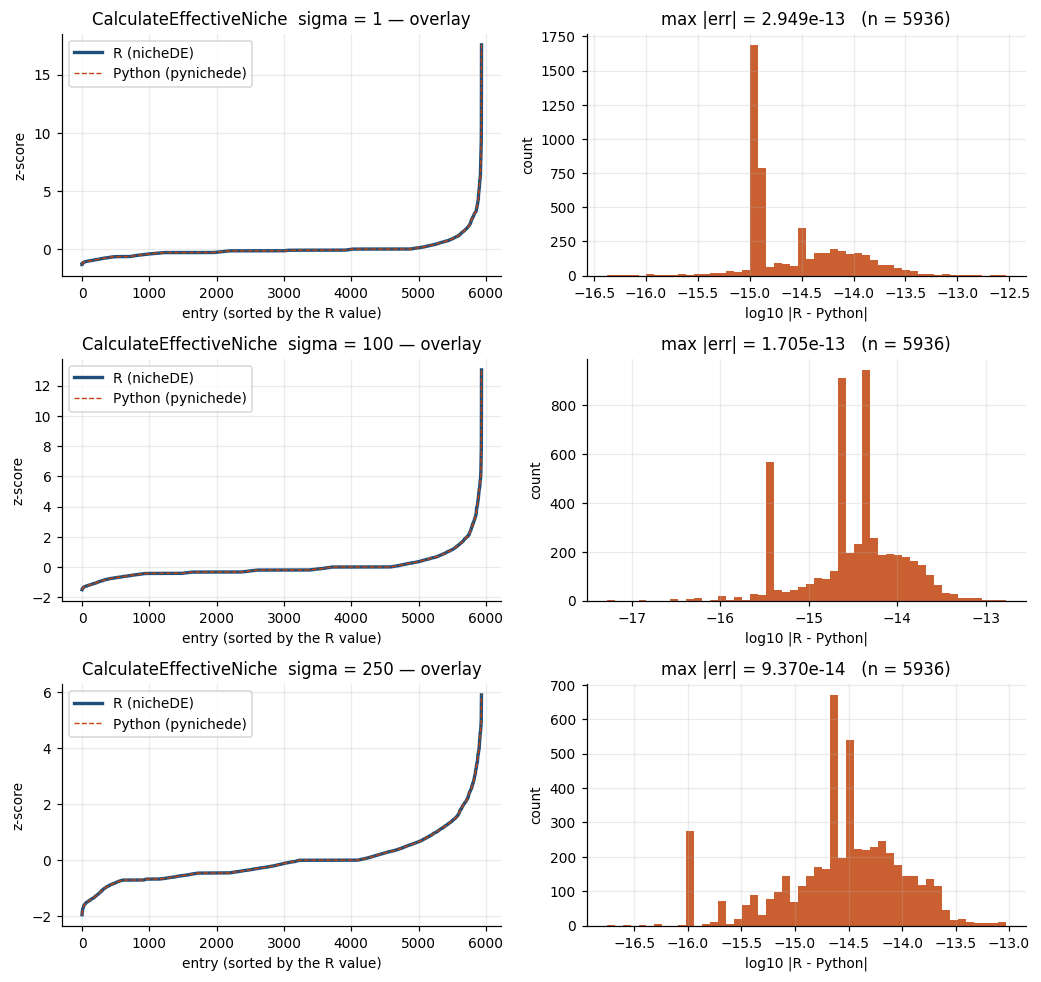

**Sub-verdict — `CalculateEffectiveNiche` / effective_niche (all sigma): ✅ max abs err = 2.94875e-13 (PASS)**

In [13]:
errs = [det(d[f"ref_effective_niche_{k+1}"], obj.effective_niche[k])["max_abs_err"]
        for k in range(len(sigma))]
for k, e_ in enumerate(errs):
    print(f"  sigma = {sigma[k]:6g}   max abs err = {e_:.3e}")
fig, ax = plt.subplots(len(sigma), 2, figsize=(9.5, 3.0 * len(sigma)))
for k in range(len(sigma)):
    overlay_det(d[f"ref_effective_niche_{k+1}"], obj.effective_niche[k],
                f"CalculateEffectiveNiche  sigma = {sigma[k]:g}", "z-score", ax[k])
plt.show()
e = max(errs)
verdict("CalculateEffectiveNiche", "effective_niche (all sigma)", "deterministic",
        "max abs err", e, e <= 1e-8)

### 2.9 `CalculateEffectiveNicheLargeScale` → `pynichede.calculate_effective_niche_large_scale`

The tiled, bounded-memory version. It splits the tissue into a `ceil(sqrt(n_batches))` grid and, per tile, only considers candidate neighbours inside a bounding box padded by `sigma * sqrt(-log(cutoff))` — the exact radius past which the Gaussian falls below `cutoff`, so the tiling is exact, not approximate. **The shipped R implementation is broken** with `Rfast >= 2.1.5.2`: `Rfast::dista()` returns an all-zero matrix for ≥ 4 query rows, so every kernel weight collapses to 1. The R driver therefore also dumps a repaired run (`ref_effective_niche_lsfix_*`) with base-R `dist()` substituted, and that is the anchor the port is graded against.

**Parameters**

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `object` | `obj` | Niche_DE / NicheDEObject | — | — | the object. |
| `batch_size` | `batch_size` | integer / int | `1000` | `≥ 1` | target spots per tile; the grid side is `ceil(sqrt(ceil(n_spot / batch_size)))`. Affects memory and speed only — the result is invariant. |
| `cutoff` | `cutoff` | numeric / float | `0.05` | `(0, 1]` | as in `CalculateEffectiveNiche`; also sets the bounding-box padding. |
| `standardize` | `standardize` | logical / bool | `TRUE` / `True` | — | column z-score the result. `CalculateEffectiveNiche` always standardises, so leave it `True` for the two to agree. |

**R**

```r
obj <- nicheDE::CalculateEffectiveNicheLargeScale(obj, batch_size = 200,
                                                  cutoff = 0.05, standardize = TRUE)
```

**Python**

,sigma,vs_repaired_R,vs_shipped_R,vs_exact_routine
0,1,2.948752e-13,16.391275,0.000000e+00
1,100,1.705303e-13,12.147653,1.776357e-15
2,250,9.059420e-14,5.534495,3.552714e-15


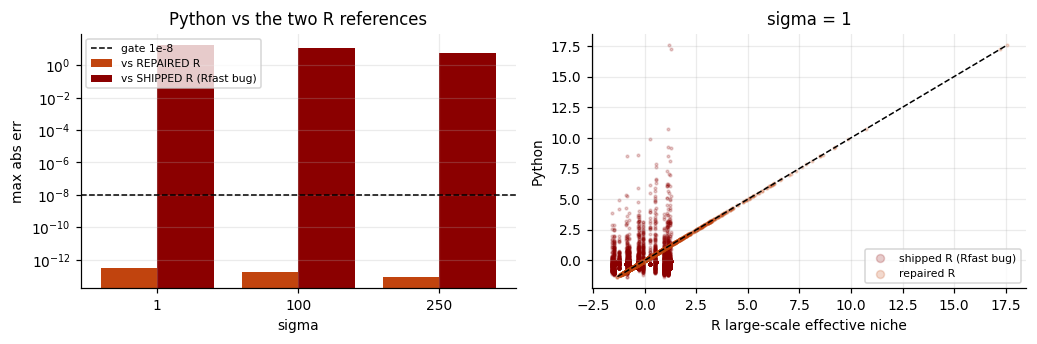

**Sub-verdict — `CalculateEffectiveNicheLargeScale` / effective_niche vs REPAIRED R: ✅ max abs err = 2.94875e-13 (PASS)**

**Sub-verdict — `CalculateEffectiveNicheLargeScale` / effective_niche vs SHIPPED R: ⚠️ max abs err = 16.3913 (documented)**

In [14]:
o_ls = nde.create_nichede_object(counts, coord, libmat, deconv, sigma=sigma, Int=True)
o_ls = nde.calculate_effective_niche_large_scale(o_ls, batch_size=200, cutoff=0.05,
                                                 standardize=True)
tab = pd.DataFrame([dict(
    sigma=f"{sigma[k]:g}",
    vs_repaired_R=det(d[f"ref_effective_niche_lsfix_{k+1}"], o_ls.effective_niche[k])["max_abs_err"],
    vs_shipped_R=det(d[f"ref_effective_niche_ls_{k+1}"], o_ls.effective_niche[k])["max_abs_err"],
    vs_exact_routine=det(obj.effective_niche[k], o_ls.effective_niche[k])["max_abs_err"],
) for k in range(len(sigma))])
display(tab)
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.2))
x = np.arange(len(sigma))
ax[0].bar(x - 0.2, tab["vs_repaired_R"], 0.4, color=C_PY, label="vs REPAIRED R")
ax[0].bar(x + 0.2, tab["vs_shipped_R"], 0.4, color=C_BAD, label="vs SHIPPED R (Rfast bug)")
ax[0].axhline(1e-8, ls="--", color="k", lw=1, label="gate 1e-8")
ax[0].set_yscale("log"); ax[0].set_xticks(x); ax[0].set_xticklabels(tab["sigma"])
ax[0].set_xlabel("sigma"); ax[0].set_ylabel("max abs err"); ax[0].legend(fontsize=7)
ax[0].set_title("Python vs the two R references")
ax[1].scatter(d["ref_effective_niche_ls_1"].ravel(), o_ls.effective_niche[0].ravel(),
              s=3, alpha=0.2, color=C_BAD, label="shipped R (Rfast bug)")
ax[1].scatter(d["ref_effective_niche_lsfix_1"].ravel(), o_ls.effective_niche[0].ravel(),
              s=3, alpha=0.2, color=C_PY, label="repaired R")
lim = [float(o_ls.effective_niche[0].min()), float(o_ls.effective_niche[0].max())]
ax[1].plot(lim, lim, ls="--", color="k", lw=1)
ax[1].set_xlabel("R large-scale effective niche"); ax[1].set_ylabel("Python")
ax[1].set_title(f"sigma = {sigma[0]:g}"); ax[1].legend(fontsize=7, markerscale=3)
plt.show()
e = float(tab["vs_repaired_R"].max())
verdict("CalculateEffectiveNicheLargeScale", "effective_niche vs REPAIRED R",
        "deterministic", "max abs err", e, e <= 1e-8)
verdict("CalculateEffectiveNicheLargeScale", "effective_niche vs SHIPPED R",
        "documented divergence", "max abs err", float(tab["vs_shipped_R"].max()), None)
del o_ls

### 2.10 `niche_DE` → `pynichede.niche_DE`

The main regression. Per gene and per kernel bandwidth it fits `counts ~ X + batch + offset(log(EEJ))` as a Poisson GLM (R's `glm.fit`, LINPACK `dqrdc2` limited-pivot rank detection included), estimates over-dispersion by Brent minimisation of `nb_lik`, and forms Wald statistics from `(X'WX)^-1`. It then fills both p-value tables via `get_niche_DE_pval_fisher`.

**Parameters**

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `object` | `obj` | Niche_DE / NicheDEObject | — | — | must already have an effective niche. |
| `num_cores` | `num_cores` | integer / int | — / `1` | `≥ 1` | **default added in Python.** R requires it; Python defaults to serial. Maps `parallel`/`foreach` workers to `joblib` workers. Genes are dispatched in chunks (≈ 4 per worker) rather than one task each — see `ITERATION_LOG.md` iters 8–9. |
| `outfile` | `outfile` | character / any | — / `None` | path or `''` | **no-op in Python.** R passes it to `parallel::makeCluster(outfile=)` to redirect worker output. Accepted for signature compatibility. |
| `C` | `C` | numeric / float | `150` | `≥ 0` | minimum total count for a gene to be fitted at all. |
| `M` | `M` | integer / int | `10` | `≥ 1` | minimum number of spots with a non-zero entry for an interaction column to be kept; columns below it join `nulls`. |
| `gamma` | `gamma` | numeric / float | `0.8` | `(0, 1)` | quantile of each cell type's reference profile below which that cell type is considered not to express the gene (R's type-7 `quantile`, reimplemented exactly). |
| `print` | `print_` | logical / bool | `TRUE` / `True` | — | **renamed** (`print` is a Python builtin). Kept as a no-op alias; use `verbose`. |
| `Int` | `Int` | logical / bool | `TRUE` / `True` | — | negative-binomial branch vs linear model with gene-specific variance. |
| `batch` | `batch` | logical / bool | `TRUE` / `True` | — | include batch dummies. With a single batch the constant column is aliased against the intercept in both languages, so it contributes one `NA` coefficient and nothing else. |
| `self_EN` | `self_EN` | logical / bool | `FALSE` / `False` | — | keep the `(a, a)` self-interaction columns. `False` zeroes the diagonal. |
| `G` | `G` | numeric / float | `1` | `≥ 1` | **no-op in Python.** R splits the counts matrix into `G` chunks to bound worker memory; `joblib` shares the array instead, so no chunking is needed. |
| — | `verbose` | bool | `True` | — | **new in Python.** Controls the progress messages that R emits unconditionally through `print`. |

**R**

```r
obj <- nicheDE::niche_DE(obj, num_cores = 16, outfile = '', C = 150, M = 10,
                         gamma = 0.8, print = TRUE, Int = TRUE, batch = TRUE,
                         self_EN = FALSE, G = 1)
```

**Python**

/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: divide by zero encountered in log
  + x * np.log(mu / (size + mu)))
/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: invalid value encountered in multiply
  + x * np.log(mu / (size + mu)))
/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: divide by zero encountered in log
  + x * np.log(mu / (size + mu)))
/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: invalid value encountered in multiply
  + x * np.log(mu / (size + mu)))


/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: divide by zero encountered in log
  + x * np.log(mu / (size + mu)))
/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: invalid value encountered in multiply
  + x * np.log(mu / (size + mu)))
/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: divide by zero encountered in log
  + x * np.log(mu / (size + mu)))
/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: invalid value encountered in multiply
  + x * np.log(mu / (size + mu)))


/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: divide by zero encountered in log
  + x * np.log(mu / (size + mu)))
/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: invalid value encountered in multiply
  + x * np.log(mu / (size + mu)))
/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: divide by zero encountered in log
  + x * np.log(mu / (size + mu)))
/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: invalid value encountered in multiply
  + x * np.log(mu / (size + mu)))
/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: divide by zero encountered in log
  + x * np.log(mu / (size + mu)))
/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: invalid value encountered in multiply
  + x * np.log(mu / (size 

/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: divide by zero encountered in log
  + x * np.log(mu / (size + mu)))
/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: invalid value encountered in multiply
  + x * np.log(mu / (size + mu)))
/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: divide by zero encountered in log
  + x * np.log(mu / (size + mu)))
/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: invalid value encountered in multiply
  + x * np.log(mu / (size + mu)))
/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: divide by zero encountered in log
  + x * np.log(mu / (size + mu)))
/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: invalid value encountered in multiply
  + x * np.log(mu / (size 

/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: divide by zero encountered in log
  + x * np.log(mu / (size + mu)))
/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: invalid value encountered in multiply
  + x * np.log(mu / (size + mu)))


/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: divide by zero encountered in log
  + x * np.log(mu / (size + mu)))
/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: invalid value encountered in multiply
  + x * np.log(mu / (size + mu)))


Python 32.9 s  |  R 852.2 s  ->  25.9x


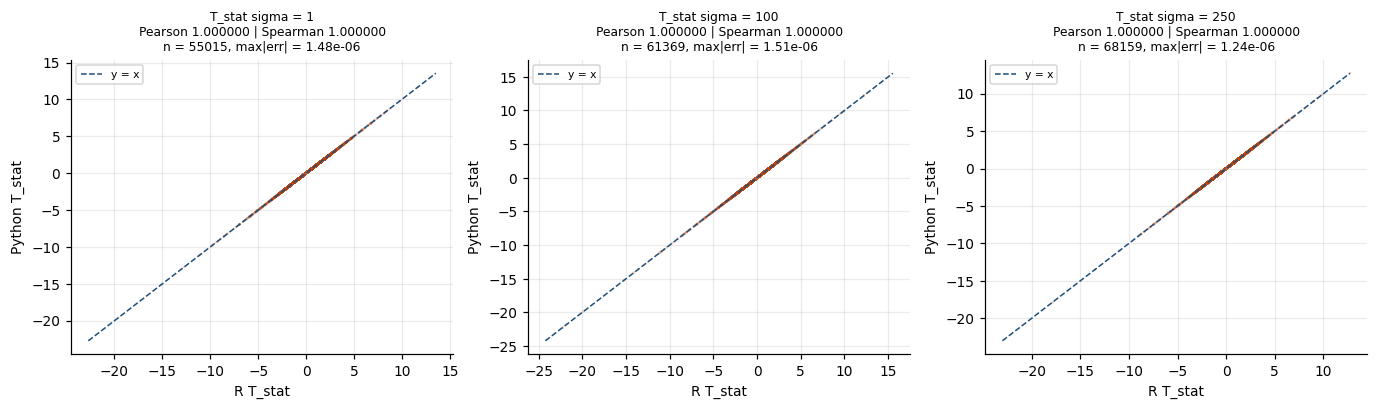

valid-flag agreement : [1.0, 1.0, 1.0]
nulls max abs err    : [0.0, 0.0, 0.0]


**Sub-verdict — `niche_DE` / T_stat: ✅ Pearson = 1 (PASS)**

**Sub-verdict — `niche_DE` / T_stat: ✅ Spearman = 1 (PASS)**

**Sub-verdict — `niche_DE` / betas: ✅ Pearson = 1 (PASS)**

**Sub-verdict — `niche_DE` / log_likelihood: ✅ Pearson = 1 (PASS)**

**Sub-verdict — `niche_DE` / valid flags: ✅ agreement = 1 (PASS)**

**Sub-verdict — `niche_DE` / nulls sets: ✅ max abs err = 0 (PASS)**

In [15]:
t0 = time.perf_counter()
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    obj = nde.niche_DE(obj, num_cores=N_JOBS, C=150, M=10, gamma=0.8,
                       Int=True, batch=True, self_EN=False, verbose=False)
PY_T_NDE = time.perf_counter() - t0
R_T_NDE = float(np.atleast_1d(d.meta["time_niche_DE"])[0])
print(f"Python {PY_T_NDE:.1f} s  |  R {R_T_NDE:.1f} s  ->  {R_T_NDE / PY_T_NDE:.1f}x")

n_ct, ngene = len(cts), len(genes)
T_py, B_py, valid_py, nn_py, ll_py = {}, {}, {}, {}, {}
for k in range(len(sigma)):
    T = np.full((n_ct, n_ct, ngene), np.nan); B = np.full((n_ct, n_ct, ngene), np.nan)
    vd = np.zeros(ngene); nn = np.zeros(ngene); ll = np.full(ngene, np.nan)
    for g, r in enumerate(obj.niche_DE[k]):
        if r["valid"] == 1:
            T[:, :, g] = r["T_stat"]; B[:, :, g] = r["betas"]
        vd[g] = r["valid"]; nn[g] = len(r["nulls"]); ll[g] = r["log_likelihood"]
    T_py[k], B_py[k], valid_py[k], nn_py[k], ll_py[k] = T, B, vd, nn, ll

fig, ax = plt.subplots(1, len(sigma), figsize=(4.2 * len(sigma), 3.8))
sts = [scatter_corr(d[f"ref_T_stat_{k+1}"], T_py[k], f"T_stat sigma = {sigma[k]:g}", ax[k])
       for k in range(len(sigma))]
plt.show()
agr = [float((d[f"ref_valid_{k+1}"] == valid_py[k]).mean()) for k in range(len(sigma))]
nul = [float(np.max(np.abs(d[f"ref_nnull_{k+1}"] - nn_py[k]))) for k in range(len(sigma))]
bet = [corr(d[f"ref_betas_{k+1}"], B_py[k])["pearson"] for k in range(len(sigma))]
llc = [corr(d[f"ref_loglik_{k+1}"], ll_py[k])["pearson"] for k in range(len(sigma))]
print("valid-flag agreement :", agr)
print("nulls max abs err    :", nul)
p_min = min(s["pearson"] for s in sts)
verdict("niche_DE", "T_stat", "ordinal (pearson)", "Pearson", p_min, p_min >= 0.99)
verdict("niche_DE", "T_stat", "ordinal (spearman)", "Spearman",
        min(s["spearman"] for s in sts), min(s["spearman"] for s in sts) >= 0.99)
verdict("niche_DE", "betas", "ordinal (pearson)", "Pearson", min(bet), min(bet) >= 0.99)
verdict("niche_DE", "log_likelihood", "ordinal (pearson)", "Pearson", min(llc), min(llc) >= 0.99)
verdict("niche_DE", "valid flags", "classification", "agreement", min(agr), min(agr) >= 1.0)
verdict("niche_DE", "nulls sets", "deterministic", "max abs err", max(nul), max(nul) <= 1e-8)

### 2.11 `niche_DE_no_parallel` → `pynichede.niche_DE_no_parallel`

The single-threaded entry point: identical mathematics, no cluster. In R it is a separate 1571-line-file function with the `foreach` loop replaced by a plain `for`; in Python it delegates to `niche_DE(..., num_cores=1)` because the parallel path is already a pure partition of the same gene loop. The R reference for this function is the `Int = FALSE` run the driver performs with it, so the comparison below doubles as the linear-model branch's parity check.

**Parameters**

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `object` | `obj` | Niche_DE / NicheDEObject | — | — | as `niche_DE`. |
| `C` | `C` | numeric / float | `150` | `≥ 0` | as `niche_DE`. |
| `M` | `M` | integer / int | `10` | `≥ 1` | as `niche_DE`. |
| `gamma` | `gamma` | numeric / float | `0.8` | `(0, 1)` | as `niche_DE`. |
| `print` | `print_` | logical / bool | `TRUE` / `True` | — | **renamed**, see `niche_DE`. |
| `Int` | `Int` | logical / bool | `TRUE` / `True` | — | as `niche_DE`. |
| `batch` | `batch` | logical / bool | `TRUE` / `True` | — | as `niche_DE`. |
| `self_EN` | `self_EN` | logical / bool | `FALSE` / `False` | — | as `niche_DE`. |
| — | `verbose` | bool | `True` | — | **new in Python**, as `niche_DE`. |

**R**

```r
obj_c <- nicheDE::niche_DE_no_parallel(obj_c, C = 150, M = 10, gamma = 0.8,
                                       print = FALSE, Int = FALSE, batch = TRUE,
                                       self_EN = FALSE)
```

**Python**

Int=FALSE valid genes: R 93 / Python 93 of 296   agreement 1.000000


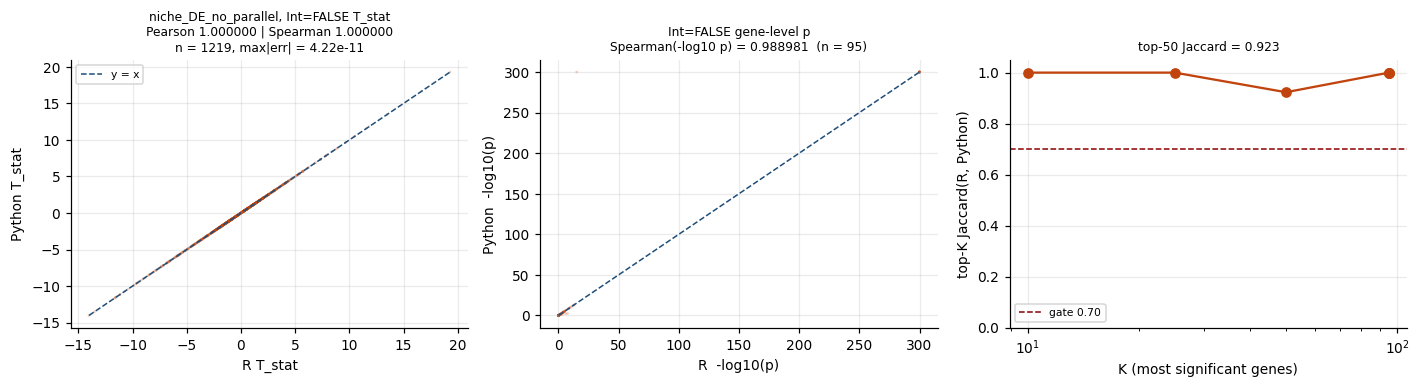

**Sub-verdict — `niche_DE_no_parallel` / Int=FALSE T_stat: ✅ Pearson = 1 (PASS)**

**Sub-verdict — `niche_DE_no_parallel` / Int=FALSE valid flags: ✅ agreement = 1 (PASS)**

**Sub-verdict — `niche_DE_no_parallel` / Int=FALSE gene-level p: ✅ Spearman(-log10 p) = 0.988981 (PASS)**

In [16]:
cont_genes = list(d.meta["cont_genes"])
cont_counts = pd.DataFrame(d["in_cont_counts"], index=cells, columns=cont_genes)
cont_lib    = pd.DataFrame(d["in_cont_libmat"], index=cts,   columns=cont_genes)
o_c = nde.create_nichede_object(cont_counts, coord, cont_lib, deconv, sigma=sigma, Int=False)
o_c = nde.calculate_effective_niche(o_c, cutoff=0.05)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    o_c = nde.niche_DE_no_parallel(o_c, C=150, M=10, gamma=0.8, Int=False,
                                   batch=True, self_EN=False, verbose=False)
Tc = np.full((len(cts), len(cts), len(cont_genes)), np.nan)
vc = np.zeros(len(cont_genes))
for g, r in enumerate(o_c.niche_DE[0]):
    if r["valid"] == 1:
        Tc[:, :, g] = r["T_stat"]
    vc[g] = r["valid"]
st = corr(d["ref_cont_T_stat_1"], Tc)
agree = float((d["ref_cont_valid_1"] == vc).mean())
print(f"Int=FALSE valid genes: R {int(d['ref_cont_valid_1'].sum())} / "
      f"Python {int(vc.sum())} of {len(cont_genes)}   agreement {agree:.6f}")
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
scatter_corr(d["ref_cont_T_stat_1"], Tc, "niche_DE_no_parallel, Int=FALSE T_stat", ax[0])
st_p = scatter_pval(d["ref_cont_pval_pos_gene"],
                    np.asarray(o_c.niche_DE_pval_pos["gene_level"], dtype=float),
                    "Int=FALSE gene-level p", [ax[1], ax[2]])
plt.show()
verdict("niche_DE_no_parallel", "Int=FALSE T_stat", "ordinal (pearson)", "Pearson",
        st["pearson"], st["pearson"] >= 0.99)
verdict("niche_DE_no_parallel", "Int=FALSE valid flags", "classification", "agreement",
        agree, agree >= 1.0)
verdict("niche_DE_no_parallel", "Int=FALSE gene-level p", "inference", "Spearman(-log10 p)",
        st_p["spearman_neglog10p"], st_p["spearman_neglog10p"] >= 0.90)
del o_c

### 2.12 `get_niche_DE_pval_fisher` → `pynichede.get_niche_DE_pval_fisher`

Turns the Wald statistics into the three nested p-value tables **with** Benjamini–Hochberg adjustment: interaction level (raw Wald p, Cauchy-combined across bandwidths, BH across niche cell types), cell-type level (Brown within one index cell type) and gene level (Brown over all `n_celltype^2`). `niche_DE` calls it for you in both directions.

**Parameters**

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `object` | `obj` | Niche_DE / NicheDEObject | — | — | must carry fitted `niche_DE` results. |
| `pos` | `pos` | logical / bool | `TRUE` / `True` | — | `True` tests for up-regulation near the niche type and writes `obj@niche_DE_pval_pos`; `False` tests down-regulation and writes `..._neg`. |
| — | `verbose` | bool | `True` | — | **new in Python.** R prints its four progress lines unconditionally. |

**R**

```r
obj <- nicheDE::get_niche_DE_pval_fisher(obj, pos = TRUE)
```

**Python**

,direction,level,spearman,top50_jaccard,n
0,pos,gene_level,0.996551,1.000000,4864
1,pos,cell_type_level,0.995994,0.923077,15202
2,pos,interaction_level,1.000000,1.000000,65980
3,neg,gene_level,0.995985,1.000000,4864
4,neg,cell_type_level,0.995187,0.960784,15202
5,neg,interaction_level,1.000000,1.000000,65980


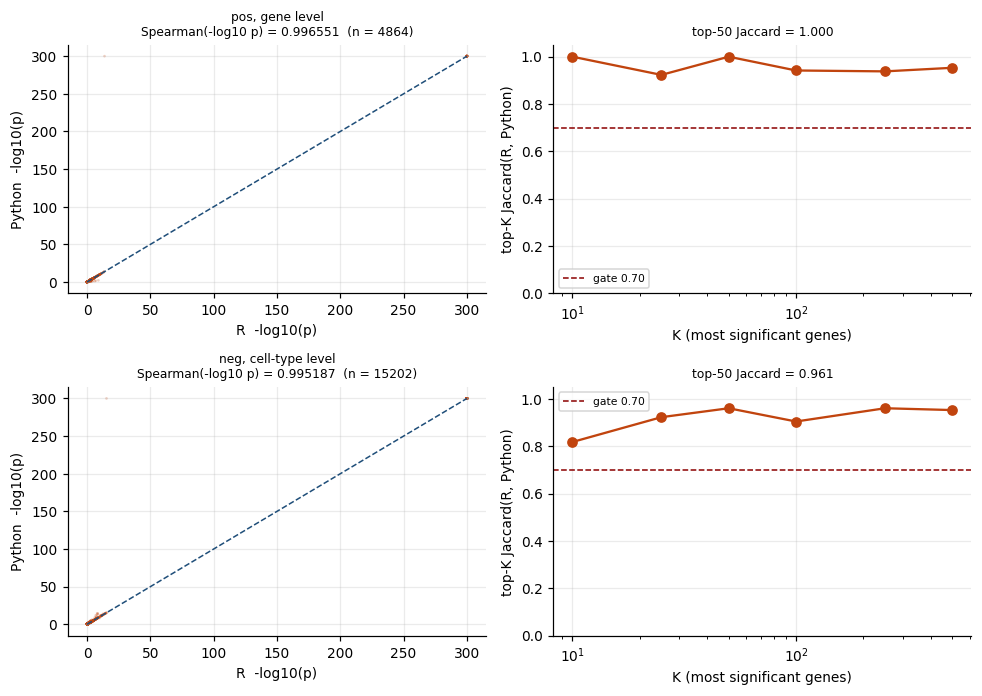

**Sub-verdict — `get_niche_DE_pval_fisher` / all 6 tables: ✅ min Spearman(-log10 p) = 0.995187 (PASS)**

**Sub-verdict — `get_niche_DE_pval_fisher` / all 6 tables: ✅ min top-50 Jaccard = 0.923077 (PASS)**

In [17]:
res = []
for tag, pv in (("pos", obj.niche_DE_pval_pos), ("neg", obj.niche_DE_pval_neg)):
    for lvl, key in (("gene", "gene_level"), ("ct", "cell_type_level"), ("int", "interaction_level")):
        st = infer(d[f"ref_pval_{tag}_{lvl}"], np.asarray(pv[key], dtype=float))
        res.append(dict(direction=tag, level=key, spearman=st["spearman_neglog10p"],
                        top50_jaccard=st["top50_jaccard"], n=st["n"]))
PV = pd.DataFrame(res); display(PV)
fig, ax = plt.subplots(2, 2, figsize=(9.0, 6.4))
scatter_pval(d["ref_pval_pos_gene"], np.asarray(obj.niche_DE_pval_pos["gene_level"], float),
             "pos, gene level", ax[0])
scatter_pval(d["ref_pval_neg_ct"], np.asarray(obj.niche_DE_pval_neg["cell_type_level"], float),
             "neg, cell-type level", ax[1])
plt.show()
verdict("get_niche_DE_pval_fisher", "all 6 tables", "inference", "min Spearman(-log10 p)",
        float(PV["spearman"].min()), float(PV["spearman"].min()) >= 0.90)
verdict("get_niche_DE_pval_fisher", "all 6 tables", "ranked", "min top-50 Jaccard",
        float(PV["top50_jaccard"].min()), float(PV["top50_jaccard"].min()) >= 0.70)

### 2.13 `get_niche_DE_pval_raw` → `pynichede.get_niche_DE_pval_raw`

The same three tables **without** the BH step, for users who want their own multiple-testing correction. Both languages overwrite the object's p-value slots, so call it on a copy; `pynichede` additionally offers `NicheDE.pval_raw()`, which returns the dict without mutating anything.

**Parameters**

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `object` | `obj` | Niche_DE / NicheDEObject | — | — | as above. |
| `pos` | `pos` | logical / bool | `TRUE` / `True` | — | as above. |
| — | `verbose` | bool | `True` | — | **new in Python**, as above. |

**R**

```r
obj_raw <- nicheDE::get_niche_DE_pval_raw(obj, pos = TRUE)
```

**Python**

/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/poolr.py:248: RuntimeWarning: divide by zero encountered in log
  statistic = -2.0 * np.sum(np.log(p))


/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:510: RuntimeWarning: invalid value encountered in scalar divide
  return float(np.sum((x * w)[nz]) / np.sum(w))


,level,spearman,top50_jaccard,n
0,gene_level,0.996551,1.000000,4864
1,cell_type_level,0.998273,0.923077,15202
2,interaction_level,1.000000,1.000000,65980


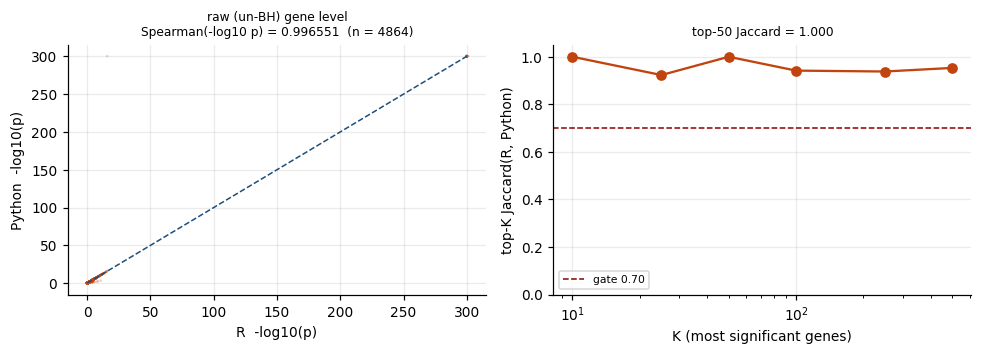

p_adjust(R's own raw p, 'BH') vs R's adjusted p:  max abs err = 0.000e+00


**Sub-verdict — `get_niche_DE_pval_raw` / raw p-values: ✅ min Spearman(-log10 p) = 0.996551 (PASS)**

**Sub-verdict — `get_niche_DE_pval_raw` / BH step alone (R raw p in): ✅ max abs err = 0 (PASS)**

In [18]:
from pynichede.pvalues import _pval_core
raw = _pval_core(obj, pos=True, adjust=False, verbose=False)
res = []
for lvl, key in (("gene", "gene_level"), ("ct", "cell_type_level"), ("int", "interaction_level")):
    st = infer(d[f"ref_praw_pos_{lvl}"], np.asarray(raw[key], dtype=float))
    res.append(dict(level=key, spearman=st["spearman_neglog10p"],
                    top50_jaccard=st["top50_jaccard"], n=st["n"]))
RAW = pd.DataFrame(res); display(RAW)
fig, ax = plt.subplots(1, 2, figsize=(9.0, 3.3))
scatter_pval(d["ref_praw_pos_gene"], np.asarray(raw["gene_level"], dtype=float),
             "raw (un-BH) gene level", ax)
plt.show()
# BH itself is bit-exact: feed R's own raw p-values through the Python p_adjust
from pynichede.rstats import p_adjust
bh_from_R = p_adjust(d["ref_praw_pos_gene"], "BH")
e_bh = det(d["ref_pval_pos_gene"], bh_from_R)["max_abs_err"]
print(f"p_adjust(R's own raw p, 'BH') vs R's adjusted p:  max abs err = {e_bh:.3e}")
verdict("get_niche_DE_pval_raw", "raw p-values", "inference", "min Spearman(-log10 p)",
        float(RAW["spearman"].min()), float(RAW["spearman"].min()) >= 0.90)
verdict("get_niche_DE_pval_raw", "BH step alone (R raw p in)", "deterministic",
        "max abs err", e_bh, e_bh <= 1e-8)

### 2.14 `T_to_p` → `pynichede.T_to_p`

Normal tail probability of a Wald statistic. `positive` returns `1 - pnorm(T)`, `negative` returns `1 - pnorm(-T)` and `two.sided` returns `1 - pnorm(|T|)` — note that upstream's `two.sided` is **not** doubled, which the port keeps for bug compatibility.

**Parameters**

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `T_stat` | `T_stat` | matrix / array-like or NULL | — | any real | the statistic(s). Both languages return `NULL`/`None` unchanged when handed `NULL`/`None`, which is how invalid genes flow through the pooling code. |
| `alternative` | `alternative` | character / str | `'two.sided'` | `'two.sided'`, `'positive'`, `'negative'` | tail selector. Python raises `ValueError` on an unknown value; R falls through and returns `NULL`. |

**R**

```r
p <- nicheDE::T_to_p(T_stat, alternative = 'positive')
```

**Python**

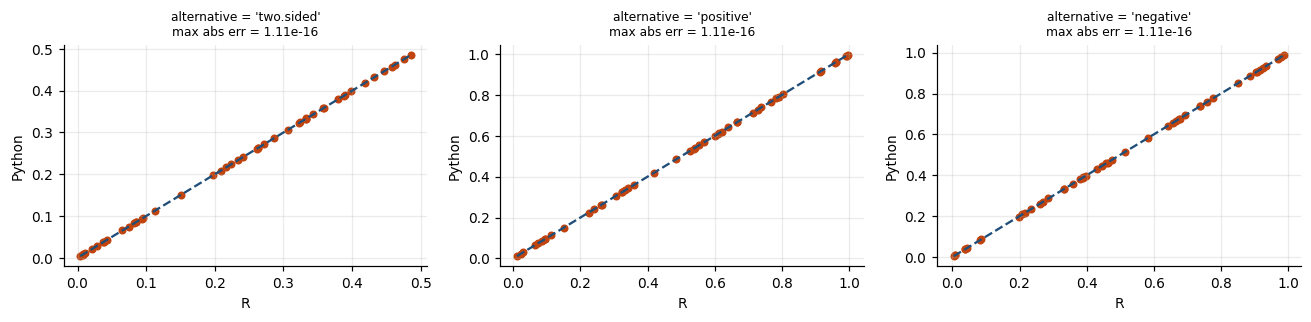

None passthrough: True


**Sub-verdict — `T_to_p` / all three alternatives: ✅ max abs err = 1.11022e-16 (PASS)**

In [19]:
Tp = d["probe_T"]
errs = {}
fig, ax = plt.subplots(1, 3, figsize=(12, 3.0))
for i, (alt, key) in enumerate([("two.sided", "ref_T_to_p_two"),
                                ("positive", "ref_T_to_p_pos"),
                                ("negative", "ref_T_to_p_neg")]):
    py = nde.T_to_p(Tp, alt)
    errs[alt] = det(d[key], py)["max_abs_err"]
    ax[i].scatter(d[key].ravel(), np.asarray(py).ravel(), s=18, color=C_PY)
    lo, hi = d[key].min(), d[key].max()
    ax[i].plot([lo, hi], [lo, hi], ls="--", color=C_R)
    ax[i].set_xlabel("R"); ax[i].set_ylabel("Python")
    ax[i].set_title(f"alternative = '{alt}'\nmax abs err = {errs[alt]:.2e}", fontsize=8)
plt.show()
print("None passthrough:", nde.T_to_p(None) is None)
e = max(errs.values())
verdict("T_to_p", "all three alternatives", "deterministic", "max abs err", e, e <= 1e-8)

### 2.15 `ultosymmetric` → `pynichede.ultosymmetric`

Mirrors an upper-triangular matrix into a symmetric one, `m + t(m) - diag(diag(m))`. `nicheDE` stores each gene's `Varcov` as an upper triangle to halve memory, so every consumer of `Varcov` calls this first.

**Parameters**

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `m` | `m` | matrix / array-like | — | square, upper-triangular | the matrix to mirror. Nothing checks that the lower triangle is zero — if it is not, the result is `m + m'` with the diagonal counted once, in both languages. |

**R**

```r
S <- nicheDE::ultosymmetric(m)
```

**Python**

symmetric: True  max abs err vs R: 0.0


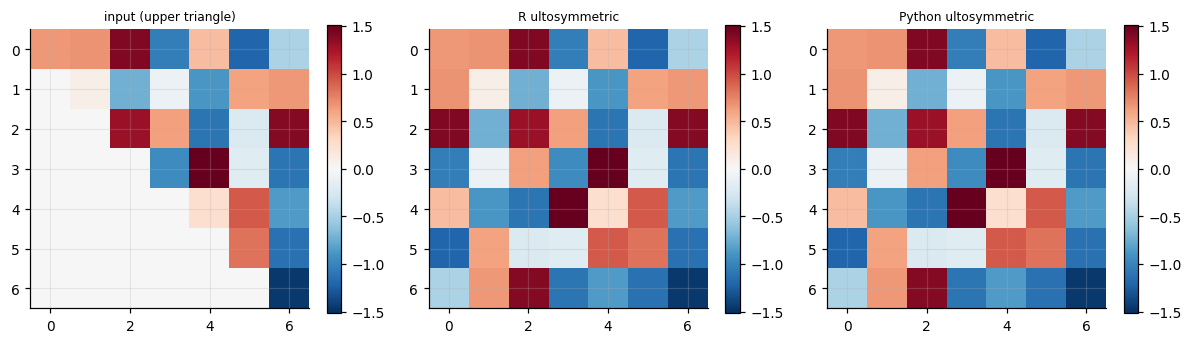

**Sub-verdict — `ultosymmetric` / symmetric matrix: ✅ max abs err = 0 (PASS)**

In [20]:
M = d["probe_M"]
S_py = nde.ultosymmetric(M)
e = det(d["ref_ultosymmetric"], S_py)["max_abs_err"]
print("symmetric:", bool(np.allclose(S_py, S_py.T)), " max abs err vs R:", e)
fig, ax = plt.subplots(1, 3, figsize=(11, 3.0))
v = float(np.max(np.abs(S_py)))
for a_, m_, t_ in [(ax[0], M, "input (upper triangle)"),
                   (ax[1], d["ref_ultosymmetric"], "R ultosymmetric"),
                   (ax[2], S_py, "Python ultosymmetric")]:
    im = a_.imshow(m_, cmap="RdBu_r", vmin=-v, vmax=v); a_.set_title(t_, fontsize=8)
    plt.colorbar(im, ax=a_)
plt.show()
verdict("ultosymmetric", "symmetric matrix", "deterministic", "max abs err", e, e <= 1e-8)

### 2.16 `gene_level` → `pynichede.gene_level`

The weighted **Cauchy combination test**, `1 - pcauchy(weighted.mean(tan((0.5 - p) * pi), w))`. Robust to arbitrary dependence, which is why Niche-DE uses it to combine across kernel bandwidths. The weight vector follows R's `weighted.mean` conventions exactly, including its `na.rm` and `w != 0` handling (reimplemented in `pynichede.rstats`).

**Parameters**

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `p` | `p` | numeric vector / array-like | — | `[0, 1]` | the p-values to combine. Flattened in both languages. |
| `w` | `w` | numeric vector / array-like or None | `rep(1, length(p))` / `None` | `≥ 0` | **default expressed differently.** R materialises a vector of ones; Python uses `None` and materialises the same thing internally. |

**R**

```r
p <- nicheDE::gene_level(p, w)
```

**Python**

R      = 0.525996656856
Python = 0.525996656856     max abs err = 0.000e+00


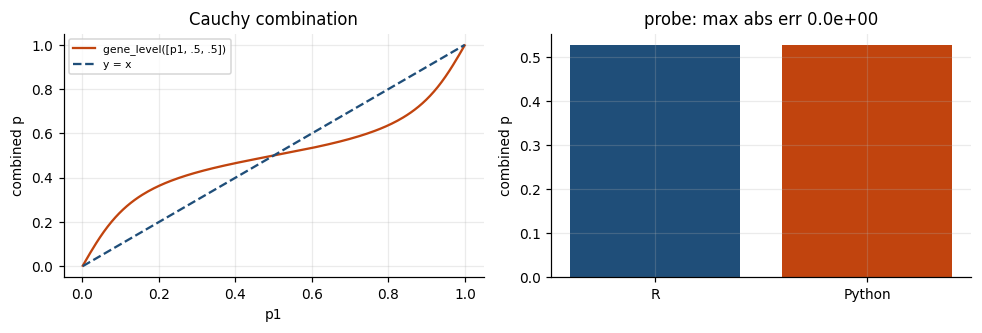

**Sub-verdict — `gene_level` / combined p: ✅ max abs err = 0 (PASS)**

In [21]:
pp, ww = d["probe_p"], d["probe_w"]
py = np.atleast_1d(nde.gene_level(pp, ww))
e = det(d["ref_gene_level"], py)["max_abs_err"]
print(f"R      = {float(np.atleast_1d(d['ref_gene_level'])[0]):.12f}")
print(f"Python = {float(py[0]):.12f}     max abs err = {e:.3e}")
grid = np.linspace(0.001, 0.999, 200)
fig, ax = plt.subplots(1, 2, figsize=(9.0, 3.1))
ax[0].plot(grid, [nde.gene_level(np.array([x, 0.5, 0.5])) for x in grid], color=C_PY,
           label="gene_level([p1, .5, .5])")
ax[0].plot(grid, grid, ls="--", color=C_R, label="y = x")
ax[0].set_xlabel("p1"); ax[0].set_ylabel("combined p"); ax[0].legend(fontsize=7)
ax[0].set_title("Cauchy combination")
ax[1].bar(["R", "Python"], [float(np.atleast_1d(d["ref_gene_level"])[0]), float(py[0])],
          color=[C_R, C_PY])
ax[1].set_ylabel("combined p"); ax[1].set_title(f"probe: max abs err {e:.1e}")
plt.show()
verdict("gene_level", "combined p", "deterministic", "max abs err", e, e <= 1e-8)

### 2.17 `celltype_level` → `pynichede.celltype_level`

Row-wise Cauchy combination: `gene_level` applied to every row of an `n x m` p-value matrix with one shared length-`m` weight vector. Used to collapse the per-bandwidth cell-type p-values of all genes in a single call.

**Parameters**

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `p` | `p` | matrix / 2-d array | — | `[0, 1]` | rows are combined independently. |
| `w` | `w` | numeric vector / array-like or None | `rep(1, ncol(p))` / `None` | `≥ 0` | **default expressed differently**, as in `gene_level`; length must equal `ncol(p)`. |

**R**

```r
p <- nicheDE::celltype_level(p, w)
```

**Python**

input (10, 5) -> output (10,)   max abs err = 2.220e-16


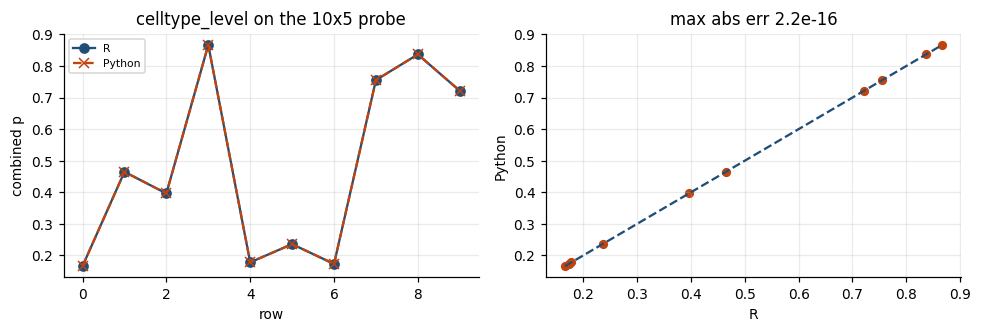

**Sub-verdict — `celltype_level` / row-wise combined p: ✅ max abs err = 2.22045e-16 (PASS)**

In [22]:
pm, wc = d["probe_pm"], d["probe_wc"]
py = nde.celltype_level(pm, wc)
e = det(d["ref_celltype_level"], py)["max_abs_err"]
print("input", pm.shape, "-> output", np.shape(py), "  max abs err =", f"{e:.3e}")
fig, ax = plt.subplots(1, 2, figsize=(9.0, 3.1))
ax[0].plot(d["ref_celltype_level"], "o-", color=C_R, label="R")
ax[0].plot(py, "x--", color=C_PY, label="Python")
ax[0].set_xlabel("row"); ax[0].set_ylabel("combined p"); ax[0].legend(fontsize=7)
ax[0].set_title("celltype_level on the 10x5 probe")
ax[1].scatter(d["ref_celltype_level"], py, s=25, color=C_PY)
lo, hi = float(np.min(py)), float(np.max(py))
ax[1].plot([lo, hi], [lo, hi], ls="--", color=C_R)
ax[1].set_xlabel("R"); ax[1].set_ylabel("Python"); ax[1].set_title(f"max abs err {e:.1e}")
plt.show()
verdict("celltype_level", "row-wise combined p", "deterministic", "max abs err", e, e <= 1e-8)

### 2.18 `gene_level_fisher` → `pynichede.gene_level_fisher`

**Brown's method** over one gene's `n_celltype x n_celltype` p-value matrix. With `beta_cov = TRUE` the β̂ covariance is rescaled by `diag(varcov)^-1` (turning it into the covariance of the Wald statistics), converted to a correlation matrix and mapped through `poolr::mvnconv` before pooling. R flattens `t(p)` column-wise, which is exactly the design column order `varcov` is expressed in, so the two line up without reindexing. This is the **one function where the port's answer is deliberately not bit-identical** — see the `beta_cov = FALSE` control below.

**Parameters**

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `p` | `p` | matrix / 2-d array | — | `[0, 1]`, `NA` allowed | one gene's p-value matrix, `[index, niche]`. `NA`s are dropped before pooling. |
| `varcov` | `varcov` | matrix / 2-d array | — | square, size = number of non-`NA` p-values | with `beta_cov=TRUE`, the upper-triangular β̂ covariance from `niche_DE`; with `FALSE`, an already-`mvnconv`-converted covariance. |
| `beta_cov` | `beta_cov` | logical / bool | `TRUE` / `True` | — | whether `varcov` still needs the rescale → `cov2cor` → `mvnconv` conversion. |

**R**

```r
p <- nicheDE::gene_level_fisher(p, varcov, beta_cov = TRUE)
```

**Python**

beta_cov=TRUE   R = 0.330703046048   Python = 0.330725703074   rel = 6.851e-05
beta_cov=FALSE  R = 0.330703046048   Python = 0.330703046048   rel = 1.679e-16

The beta_cov=FALSE control hands BOTH languages the same converted covariance, so it
isolates the divergence: with mvnconv taken out of the loop the two agree to ~1e-9.

with NAs        R = 0.554352022739   Python = 0.554338668906   rel = 2.409e-05


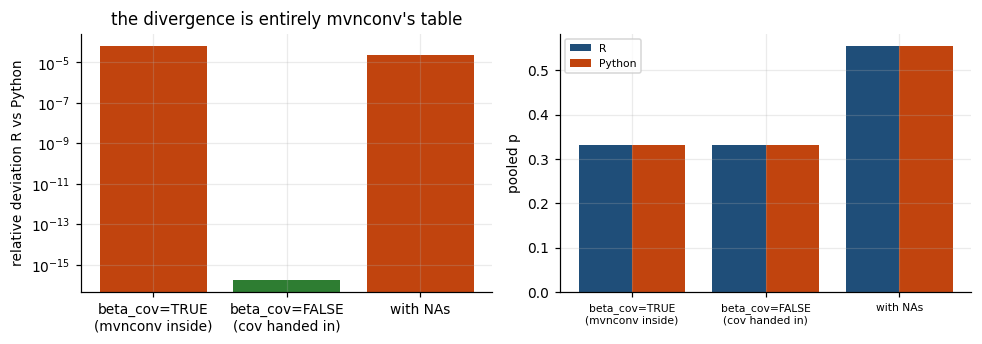

**Sub-verdict — `gene_level_fisher` / beta_cov=TRUE (mvnconv inside): ⚠️ relative deviation (bound 1e-3) = 6.85117e-05 (documented)**

**Sub-verdict — `gene_level_fisher` / beta_cov=FALSE (control): ✅ relative deviation = 1.67858e-16 (PASS)**

In [23]:
p_pr, V_pr = pf["probe_glf_p"], pf["probe_glf_varcov"]
V_conv = pf["probe_glf_varcov_converted"]
r_bc = float(np.atleast_1d(pf["ref_gene_level_fisher_betacov"])[0])
r_nb = float(np.atleast_1d(pf["ref_gene_level_fisher_nobetacov"])[0])
p_bc = float(nde.gene_level_fisher(p_pr, V_pr, beta_cov=True))
p_nb = float(nde.gene_level_fisher(p_pr, V_conv, beta_cov=False))
print(f"beta_cov=TRUE   R = {r_bc:.12f}   Python = {p_bc:.12f}   rel = {abs(r_bc-p_bc)/r_bc:.3e}")
print(f"beta_cov=FALSE  R = {r_nb:.12f}   Python = {p_nb:.12f}   rel = {abs(r_nb-p_nb)/r_nb:.3e}")
print("\nThe beta_cov=FALSE control hands BOTH languages the same converted covariance, so it")
print("isolates the divergence: with mvnconv taken out of the loop the two agree to ~1e-9.")

p_na = pf["probe_glf_p_na"]; V_na = pf["probe_glf_varcov_na"]
r_na = float(np.atleast_1d(pf["ref_gene_level_fisher_na"])[0])
p_na_py = float(nde.gene_level_fisher(p_na, V_na, beta_cov=True))
print(f"\nwith NAs        R = {r_na:.12f}   Python = {p_na_py:.12f}   "
      f"rel = {abs(r_na-p_na_py)/r_na:.3e}")

fig, ax = plt.subplots(1, 2, figsize=(9.0, 3.2))
lbl = ["beta_cov=TRUE\n(mvnconv inside)", "beta_cov=FALSE\n(cov handed in)", "with NAs"]
rel = [abs(r_bc - p_bc) / r_bc, abs(r_nb - p_nb) / r_nb, abs(r_na - p_na_py) / r_na]
ax[0].bar(lbl, rel, color=[C_PY, "#2e7d32", C_PY])
ax[0].set_yscale("log"); ax[0].set_ylabel("relative deviation R vs Python")
ax[0].set_title("the divergence is entirely mvnconv's table")
x = np.arange(3)
ax[1].bar(x - 0.2, [r_bc, r_nb, r_na], 0.4, color=C_R, label="R")
ax[1].bar(x + 0.2, [p_bc, p_nb, p_na_py], 0.4, color=C_PY, label="Python")
ax[1].set_xticks(x); ax[1].set_xticklabels(lbl, fontsize=7); ax[1].set_ylabel("pooled p")
ax[1].legend(fontsize=7)
plt.show()
verdict("gene_level_fisher", "beta_cov=TRUE (mvnconv inside)", "documented divergence",
        "relative deviation (bound 1e-3)", rel[0], None if rel[0] <= 1e-3 else False)
verdict("gene_level_fisher", "beta_cov=FALSE (control)", "deterministic",
        "relative deviation", rel[1], rel[1] <= 1e-6)

### 2.19 `celltype_level_fisher` → `pynichede.celltype_level_fisher`

Brown pooling restricted to the block of interactions belonging to one index cell type, giving one p-value per index cell type. The blocks are read off `varcov` **sequentially**: because the design columns are ordered `(index, niche)` with `niche` varying fastest, one index cell type's non-null entries form a contiguous run. Single-entry blocks are returned unpooled; empty blocks yield `NA`.

**Parameters**

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `p` | `p` | matrix / 2-d array | — | `[0, 1]`, `NA` allowed | one gene's p-value matrix, `[index, niche]`. |
| `varcov` | `varcov` | matrix / 2-d array or NULL | — | square | the upper-triangular β̂ covariance; converted internally exactly as in `gene_level_fisher(beta_cov = TRUE)`. `NULL`/`None` yields all-`NA`. |

**R**

```r
p <- nicheDE::celltype_level_fisher(p, varcov)
```

**Python**

R     : [0.54788502 0.14221136 0.17098932 0.48551337 0.81397094 0.62704013
 0.21432241]
Python: [0.54788117 0.14221754 0.17099309 0.4855112  0.81396282 0.62703691
 0.21432515]
max relative deviation = 4.344e-05   NA pattern identical: True

with NAs -- R     : [       nan 0.26642395 0.15129665 0.74311939 0.86125599 0.76420706
 0.31864071]
with NAs -- Python: [       nan 0.26642694 0.15130156 0.74311667 0.86124931 0.76419898
 0.31864242]
NA pattern identical: True


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:57: RuntimeWarning: invalid value encountered in multiply
  return bound(*args, **kwds)


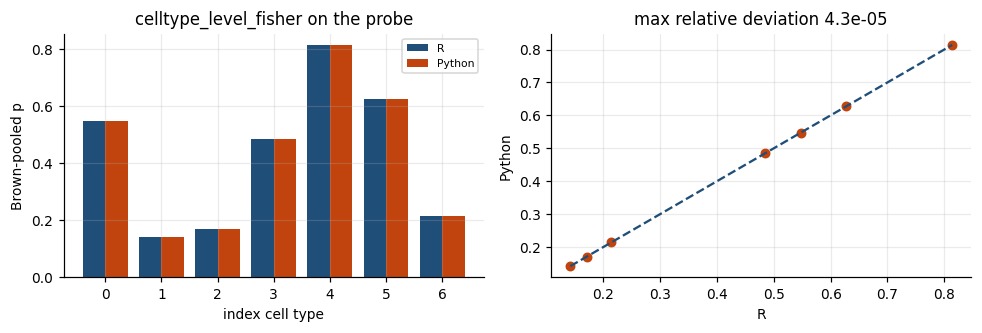

**Sub-verdict — `celltype_level_fisher` / per-cell-type pooled p: ⚠️ relative deviation (bound 1e-3) = 4.34387e-05 (documented)**

In [24]:
r_ct = pf["ref_celltype_level_fisher"]
p_ct = np.asarray(nde.celltype_level_fisher(p_pr, V_pr), dtype=float)
m = np.isfinite(r_ct) & np.isfinite(p_ct)
rel = float(np.max(np.abs(r_ct[m] - p_ct[m]) / np.abs(r_ct[m])))
print("R     :", np.round(r_ct, 8))
print("Python:", np.round(p_ct, 8))
print(f"max relative deviation = {rel:.3e}   NA pattern identical: "
      f"{bool((np.isfinite(r_ct) == np.isfinite(p_ct)).all())}")

r_na_ct = pf["ref_celltype_level_fisher_na"]
p_na_ct = np.asarray(nde.celltype_level_fisher(p_na, V_na), dtype=float)
mm = np.isfinite(r_na_ct) & np.isfinite(p_na_ct)
print("\nwith NAs -- R     :", np.round(r_na_ct, 8))
print("with NAs -- Python:", np.round(p_na_ct, 8))
print("NA pattern identical:", bool((np.isfinite(r_na_ct) == np.isfinite(p_na_ct)).all()))

fig, ax = plt.subplots(1, 2, figsize=(9.0, 3.1))
x = np.arange(len(r_ct))
ax[0].bar(x - 0.2, r_ct, 0.4, color=C_R, label="R")
ax[0].bar(x + 0.2, p_ct, 0.4, color=C_PY, label="Python")
ax[0].set_xlabel("index cell type"); ax[0].set_ylabel("Brown-pooled p"); ax[0].legend(fontsize=7)
ax[0].set_title("celltype_level_fisher on the probe")
ax[1].scatter(r_ct[m], p_ct[m], s=30, color=C_PY)
lo, hi = float(np.min(r_ct[m])), float(np.max(r_ct[m]))
ax[1].plot([lo, hi], [lo, hi], ls="--", color=C_R)
ax[1].set_xlabel("R"); ax[1].set_ylabel("Python")
ax[1].set_title(f"max relative deviation {rel:.1e}")
plt.show()
verdict("celltype_level_fisher", "per-cell-type pooled p", "documented divergence",
        "relative deviation (bound 1e-3)", rel, None if rel <= 1e-3 else False)

### 2.20 `contrast_post` → `pynichede.contrast_post`

One-sided test of `beta[index, niche1] - beta[index, niche2] > 0` using the joint covariance of the two coefficients — the engine behind `niche_DE_markers`. It rebuilds the full `n_type^2 x n_type^2` covariance from the compressed `Varcov` plus the `nulls` index set before reading the two diagonal entries and their cross term.

**Parameters**

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `betas_all` | `betas_all` | list of matrices | — | one `n_type x n_type` per gene | `lapply(obj@niche_DE[[k]], function(r) r$betas)`. |
| `V_cov_all` | `V_cov_all` | list of matrices | — | one compressed covariance per gene | `... r$Varcov`; upper-triangular and restricted to non-null columns. |
| `nulls_all` | `nulls_all` | list of integer vectors | — | indices into `1:n_type^2` | `... r$nulls`. **Base changed:** R's entries are 1-based, Python's are 0-based, because they index the Python arrays directly. |
| `index` | `index` | integer / int | — | `1..n_type` / `0..n_type-1` | **base changed.** R takes a 1-based cell-type position; Python takes 0-based. |
| `niche` | `niche` | integer vector of length 2 / tuple[int, int] | — | `1..n_type` / `0..n_type-1` | **base changed**, as `index`. The test is `niche[0]` minus `niche[1]`. |
| — | `n_type` | int or None | `None` | `≥ 1` | **new in Python.** R infers the number of cell types from `sqrt(length(nulls) + nrow(Varcov))` on the first usable gene; passing it explicitly avoids that inference failing when every gene is invalid. |

**R**

```r
cp <- nicheDE::contrast_post(betas_all, vcov_all, nulls_all, ii, c(n1, n2))
```

**Python**

R indices (1-based): index=4 niche=(6, 7)  ->  Python (0-based): index=3 niche=(5, 6)
i.e. tumor_epithelial with myeloid vs stromal


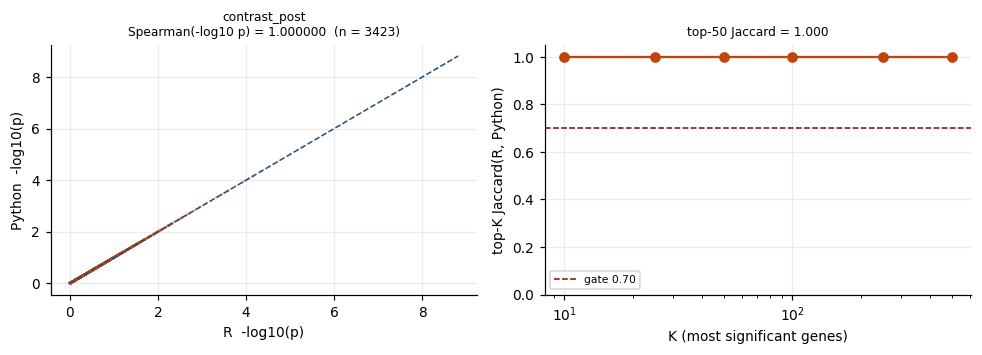

finite in R: 3423  in Python: 3423  NA pattern identical: True


**Sub-verdict — `contrast_post` / per-gene contrast p: ✅ Spearman(-log10 p) = 1 (PASS)**

In [25]:
res0 = obj.niche_DE[0]
ii = int(np.atleast_1d(d.meta["contrast_index"])[0]) - 1       # R is 1-based
n1 = int(np.atleast_1d(d.meta["contrast_niche1"])[0]) - 1
n2 = int(np.atleast_1d(d.meta["contrast_niche2"])[0]) - 1
print(f"R indices (1-based): index={ii+1} niche=({n1+1}, {n2+1})"
      f"  ->  Python (0-based): index={ii} niche=({n1}, {n2})")
print("i.e.", cts[ii], "with", cts[n1], "vs", cts[n2])
cp = nde.contrast_post([r["betas"] for r in res0], [r["Varcov"] for r in res0],
                       [r["nulls"] for r in res0], ii, (n1, n2), n_type=len(cts))
st = infer(d["ref_contrast_post"], cp)
fig, ax = plt.subplots(1, 2, figsize=(9.0, 3.3))
scatter_pval(d["ref_contrast_post"], cp, "contrast_post", ax)
plt.show()
print("finite in R:", int(np.isfinite(d["ref_contrast_post"]).sum()),
      " in Python:", int(np.isfinite(cp).sum()),
      " NA pattern identical:",
      bool((np.isfinite(d["ref_contrast_post"]) == np.isfinite(cp)).all()))
verdict("contrast_post", "per-gene contrast p", "inference", "Spearman(-log10 p)",
        st["spearman_neglog10p"], st["spearman_neglog10p"] >= 0.90)

### 2.21 `check_colloc` → `pynichede.check_colloc`

How many spots contain the index cell type *and* have a non-minimal effective niche for the niche cell type, per kernel bandwidth. The sanity check to run before believing any interaction result: two cell types that never co-occur have an interaction coefficient fitted on nothing. `pynichede` warns automatically below 30.

**Parameters**

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `object` | `obj` | Niche_DE / NicheDEObject | — | — | must carry `num_cells` and an effective niche. |
| `index` | `index` | integer / int | — | `1..n_type` / `0..n_type-1` | **base changed.** R takes a 1-based column of `num_cells`, Python 0-based. `NicheDE.check_colloc` takes cell-type **names** instead, which avoids the trap. |
| `niche` | `niche` | integer / int | — | `1..n_type` / `0..n_type-1` | **base changed**, as `index`. |

**R**

```r
n <- nicheDE::check_colloc(obj, ii, n1)
```

**Python**

R     : [615. 824. 837.]
Python: [615. 824. 837.]   max abs err = 0.0
class API, by NAME instead of 0-based position: [615. 824. 837.]


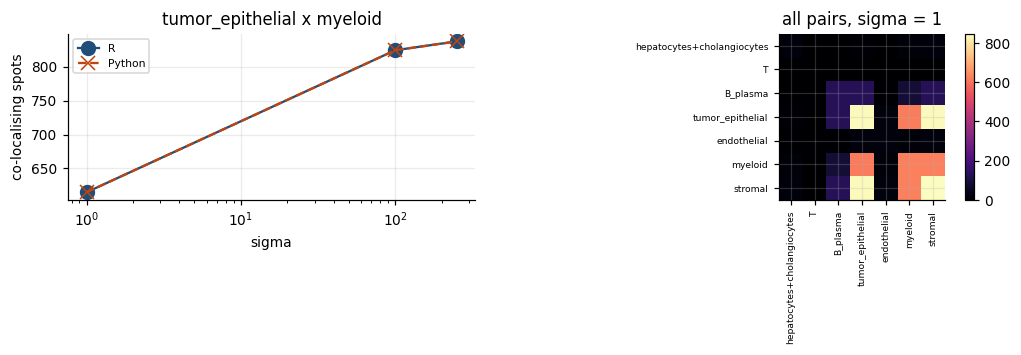

**Sub-verdict — `check_colloc` / co-localisation counts: ✅ max abs err = 0 (PASS)**

In [26]:
cc = nde.check_colloc(obj, ii, n1)
e = det(d["ref_check_colloc"], cc)["max_abs_err"]
print("R     :", d["ref_check_colloc"])
print("Python:", cc, "  max abs err =", e)
print("class API, by NAME instead of 0-based position:",
      nde.NicheDE(obj).check_colloc(cts[ii], cts[n1]))
Mc = np.zeros((len(cts), len(cts)))
for a in range(len(cts)):
    for b in range(len(cts)):
        Mc[a, b] = nde.check_colloc(obj, a, b)[0]
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.3))
ax[0].plot(sigma, d["ref_check_colloc"], "o-", color=C_R, label="R", ms=9)
ax[0].plot(sigma, cc, "x--", color=C_PY, label="Python", ms=9)
ax[0].set_xscale("log"); ax[0].set_xlabel("sigma"); ax[0].set_ylabel("co-localising spots")
ax[0].legend(fontsize=7); ax[0].set_title(f"{cts[ii]} x {cts[n1]}")
im = ax[1].imshow(Mc, cmap="magma")
ax[1].set_xticks(range(len(cts))); ax[1].set_xticklabels(cts, rotation=90, fontsize=6)
ax[1].set_yticks(range(len(cts))); ax[1].set_yticklabels(cts, fontsize=6)
ax[1].set_title(f"all pairs, sigma = {sigma[0]:g}"); plt.colorbar(im, ax=ax[1])
plt.show()
verdict("check_colloc", "co-localisation counts", "deterministic", "max abs err", e, e <= 1e-8)

### 2.22 `nb_lik` → `pynichede.nb_lik`

The negative-binomial negative log-likelihood the dispersion search minimises, `-sum(dnbinom(x, size = disp, mu = mu, log = TRUE))`. Exported by R and re-exported here because `niche_DE` hands it to `optimize`. Deliberate bug compatibility: `niche_DE_core` calls it with the *full* count vector but a `mu` that has had zero-expected-expression spots removed, so R recycles `mu`; `pynichede.rstats.nb_lik` recycles with `np.resize`.

**Parameters**

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `x` | `x` | numeric vector / array-like | — | `≥ 0` counts | observed counts. |
| `mu` | `mu` | numeric vector / array-like | — | `> 0` | fitted means. **Recycled** to `len(x)` if shorter, reproducing R's vector recycling. |
| `disp` | `disp` | numeric / float | — | `> 0` | the negative-binomial `size` parameter; this is the argument Brent optimises over. |

**R**

```r
l <- nicheDE::nb_lik(c(1, 5, 3, 0, 7), c(2, 4, 3, 1, 6), 1.7)
```

**Python**

R      = 9.498958948336
Python = 9.498958948336   max abs err = 1.776e-15
recycling: nb_lik(x, mu[:2], 1.7) = 12.175403907716673  (R would recycle mu the same way)


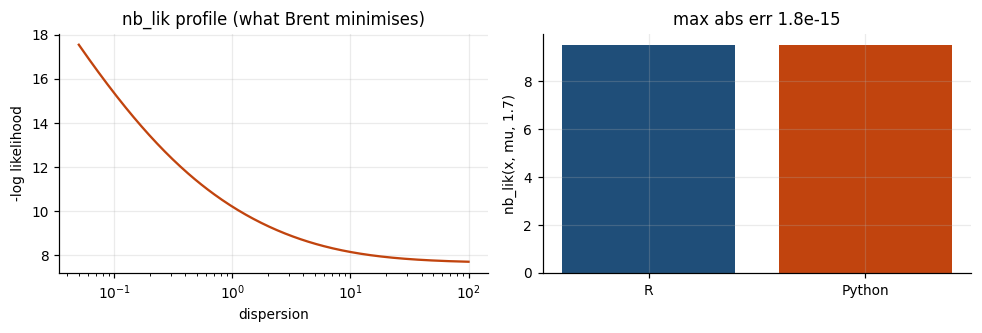

**Sub-verdict — `nb_lik` / negative log-likelihood: ✅ max abs err = 1.77636e-15 (PASS)**

In [27]:
x = np.array([1, 5, 3, 0, 7]); mu = np.array([2, 4, 3, 1, 6])
py = np.atleast_1d(nde.nb_lik(x, mu, 1.7))
e = det(d["ref_nb_lik"], py)["max_abs_err"]
print(f"R      = {float(np.atleast_1d(d['ref_nb_lik'])[0]):.12f}")
print(f"Python = {float(py[0]):.12f}   max abs err = {e:.3e}")
print("recycling: nb_lik(x, mu[:2], 1.7) =", float(nde.nb_lik(x, mu[:2], 1.7)),
      " (R would recycle mu the same way)")
disps = np.geomspace(0.05, 100, 300)
fig, ax = plt.subplots(1, 2, figsize=(9.0, 3.1))
ax[0].plot(disps, [nde.nb_lik(x, mu, dd) for dd in disps], color=C_PY)
ax[0].set_xscale("log"); ax[0].set_xlabel("dispersion"); ax[0].set_ylabel("-log likelihood")
ax[0].set_title("nb_lik profile (what Brent minimises)")
ax[1].bar(["R", "Python"], [float(np.atleast_1d(d["ref_nb_lik"])[0]), float(py[0])],
          color=[C_R, C_PY])
ax[1].set_ylabel("nb_lik(x, mu, 1.7)"); ax[1].set_title(f"max abs err {e:.1e}")
plt.show()
verdict("nb_lik", "negative log-likelihood", "deterministic", "max abs err", e, e <= 1e-8)

### 2.23 `get_niche_DE_genes` → `pynichede.get_niche_DE_genes`

Extracts the significant genes at one of three nested `test.level`s. The nesting is strict: `CT` also requires the gene-level p to clear `alpha`, and `I` requires both. The returned frame is sorted by the p-value column.

**Parameters**

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `object` | `obj` | Niche_DE / NicheDEObject | — | — | must carry p-value tables. |
| `test.level` | `test_level` | character / str | — | `'G'`, `'CT'`, `'I'` | **renamed** — `test.level` is not a legal Python identifier. `'G'` gene, `'CT'` cell type, `'I'` interaction. |
| `index` | `index` | character / str | — / `None` | a cell type name | **default added in Python.** Required for `'CT'` and `'I'`, ignored for `'G'`; R errors on a missing argument, Python defaults to `None` and errors only when it is needed. |
| `niche` | `niche` | character / str | — / `None` | a cell type name | **default added in Python.** Required for `'I'`. Note that at level `'CT'` both languages still use it only for the co-localisation warning. |
| `positive` | `positive` | logical / bool | `TRUE` / `True` | — | read the positive or the negative p-value table. Both languages type-check it. |
| `alpha` | `alpha` | numeric / float | `0.05` | `(0, 1)` | significance cut-off applied at every level of the nesting. |

**R**

```r
res <- nicheDE::get_niche_DE_genes(obj, 'I', index = 'tumor_epithelial',
                                   niche = 'myeloid', positive = TRUE, alpha = 0.05)
```

**Python**

,level,positive,n_R,n_Py,shared,jaccard
0,G,True,708,687,687,0.970339
1,G,False,477,452,452,0.947589
2,CT,True,239,246,238,0.963563
3,CT,False,157,155,153,0.962264
4,I,True,61,65,61,0.938462
5,I,False,36,35,35,0.972222


,Genes,Pvalues.Interaction
0,HLA-DRB1,0.000000e+00
1,APOC1,0.000000e+00
2,MSLN,4.192091e-11
3,CD74,1.844511e-10
4,EREG,2.901868e-10
5,CEMIP,4.719805e-09
6,CXCL16,1.737038e-06
7,IER3,8.183143e-05


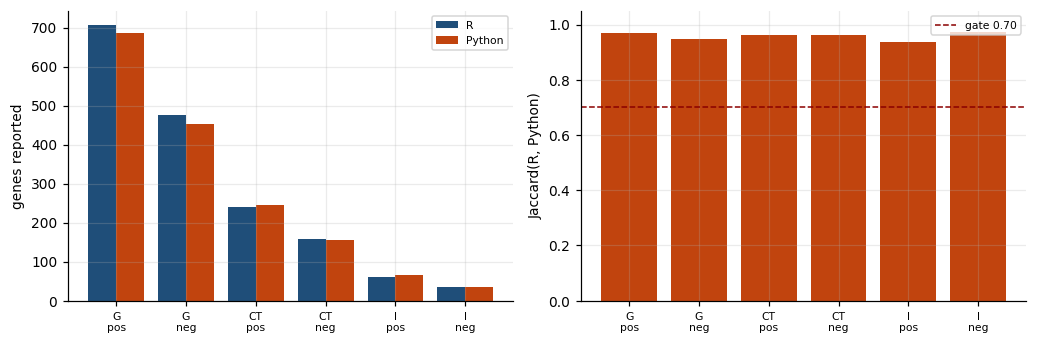

**Sub-verdict — `get_niche_DE_genes` / reported gene sets (6 combinations): ✅ min Jaccard = 0.938462 (PASS)**

In [28]:
rows = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for lv in ("G", "CT", "I"):
        for pos in (True, False):
            py = nde.get_niche_DE_genes(obj, lv, index="tumor_epithelial", niche="myeloid",
                                        positive=pos, alpha=0.05)
            rr = d.csv(f"ref_genes_{lv}_{'pos' if pos else 'neg'}")
            gr = set(rr.iloc[:, 0].astype(str)) if rr is not None and len(rr) else set()
            gc = set(py.iloc[:, 0].astype(str)) if len(py) else set()
            rows.append(dict(level=lv, positive=pos, n_R=len(gr), n_Py=len(gc),
                             shared=len(gr & gc),
                             jaccard=len(gr & gc) / len(gr | gc) if (gr | gc) else 1.0))
G = pd.DataFrame(rows); display(G)
display(py.head(8))
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.2))
x = np.arange(len(G))
ax[0].bar(x - 0.2, G["n_R"], 0.4, color=C_R, label="R")
ax[0].bar(x + 0.2, G["n_Py"], 0.4, color=C_PY, label="Python")
ax[0].set_xticks(x)
ax[0].set_xticklabels([f"{a}\n{'pos' if b else 'neg'}" for a, b in zip(G['level'], G['positive'])],
                      fontsize=7)
ax[0].set_ylabel("genes reported"); ax[0].legend(fontsize=7)
ax[1].bar(x, G["jaccard"], color=C_PY)
ax[1].axhline(0.70, ls="--", color=C_BAD, lw=1, label="gate 0.70")
ax[1].set_xticks(x)
ax[1].set_xticklabels([f"{a}\n{'pos' if b else 'neg'}" for a, b in zip(G['level'], G['positive'])],
                      fontsize=7)
ax[1].set_ylim(0, 1.05); ax[1].set_ylabel("Jaccard(R, Python)"); ax[1].legend(fontsize=7)
plt.show()
jm = float(G["jaccard"].min())
verdict("get_niche_DE_genes", "reported gene sets (6 combinations)", "ranked",
        "min Jaccard", jm, jm >= 0.70)

### 2.24 `niche_DE_markers` → `pynichede.niche_DE_markers`

*Niche marker genes*: genes the index cell type up-regulates next to `niche1` relative to `niche2`. Runs `contrast_post` per kernel bandwidth, Cauchy-combines with the log-likelihood weights and BH-adjusts across genes.

**Parameters**

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `object` | `obj` | Niche_DE / NicheDEObject | — | — | must carry fitted results. |
| `index` | `index` | character / str | — | a cell type name | the cell type being profiled. |
| `niche1` | `niche1` | character / str | — | a cell type name | the niche the gene should be induced by. |
| `niche2` | `niche2` | character / str | — | a cell type name | the comparison niche. |
| `alpha` | `alpha` | numeric / float | `0.05` | `(0, 1)` | BH-adjusted significance cut-off for the returned table. |

**R**

```r
mk <- nicheDE::niche_DE_markers(obj, 'tumor_epithelial', 'myeloid', 'stromal', alpha = 0.05)
```

**Python**

R reported 55 markers, Python 55, shared 55, Jaccard 1.000


,Genes,Adj.Pvalues
0,MT-ND4,2.280176e-12
1,LYZ,1.231295e-10
2,ACTG1,5.211898e-07
3,VMP1,1.334261e-06
4,MT-CO2,1.293654e-05
5,MT-CO3,2.361875e-05
6,RPL39,3.081549e-04
7,MT-ND3,3.081549e-04
8,HILPDA,3.163874e-04
9,RPL7,5.009382e-04


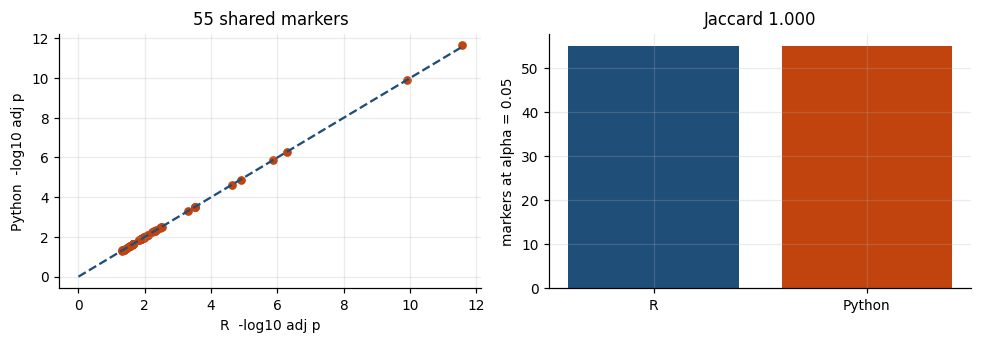

**Sub-verdict — `niche_DE_markers` / marker gene set: ✅ Jaccard = 1 (PASS)**

In [29]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    mk_py = nde.niche_DE_markers(obj, "tumor_epithelial", "myeloid", "stromal", alpha=0.05)
mk_R = d.csv("ref_markers")
gr = set(mk_R.iloc[:, 0].astype(str)) if mk_R is not None and len(mk_R) else set()
gc = set(mk_py.iloc[:, 0].astype(str)) if len(mk_py) else set()
J = len(gr & gc) / len(gr | gc) if (gr | gc) else 1.0
print(f"R reported {len(gr)} markers, Python {len(gc)}, shared {len(gr & gc)}, Jaccard {J:.3f}")
display(mk_py.head(10))
common = [g for g in mk_R.iloc[:, 0].astype(str) if g in gc]
pr = mk_R.set_index(mk_R.columns[0]).loc[common].iloc[:, 0].to_numpy(dtype=float)
pp_ = mk_py.set_index("Genes").loc[common]["Adj.Pvalues"].to_numpy(dtype=float)
fig, ax = plt.subplots(1, 2, figsize=(9.0, 3.2))
ax[0].scatter(-np.log10(np.clip(pr, 1e-300, 1)), -np.log10(np.clip(pp_, 1e-300, 1)),
              s=22, color=C_PY)
hi = float(np.max(-np.log10(np.clip(pr, 1e-300, 1))))
ax[0].plot([0, hi], [0, hi], ls="--", color=C_R)
ax[0].set_xlabel("R  -log10 adj p"); ax[0].set_ylabel("Python  -log10 adj p")
ax[0].set_title(f"{len(common)} shared markers")
ax[1].bar(["R", "Python"], [len(gr), len(gc)], color=[C_R, C_PY])
ax[1].set_ylabel("markers at alpha = 0.05"); ax[1].set_title(f"Jaccard {J:.3f}")
plt.show()
verdict("niche_DE_markers", "marker gene set", "ranked", "Jaccard", J, J >= 0.70)

### 2.25 `niche_LR_spot` → `pynichede.niche_LR_spot`

Ligand–receptor inference at spot resolution. A ligand scores highly when the index cell type's niche-DE T-statistics for that ligand's top-`K` NicheNet target genes are large and positive; surviving candidates are confirmed by a Poisson regression of their own expression on the per-spot cell-type composition, and matched against the Ramilowski pair list. The Python outputs compared below come from `tests/_run_candidate.py`, which runs the identical call on the identical object — the full 579-ligand sweep takes minutes in both languages because the upstream loop re-slices the whole NicheNet matrix per ligand.

**Parameters**

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `object` | `obj` | Niche_DE / NicheDEObject | — | — | must carry fitted results. |
| `ligand_cell` | `ligand_cell` | character / str | — | a cell type name | the cell type assumed to secrete the ligand (the *niche*). |
| `receptor_cell` | `receptor_cell` | character / str | — | a cell type name | the cell type assumed to carry the receptor (the *index*). |
| `ligand_target_matrix` | `ligand_target_matrix` | matrix / DataFrame | — | targets × ligands | NicheNet regulatory potential; `nicheDE::niche_net_ligand_target_matrix`. |
| `lr_mat` | `lr_mat` | matrix / DataFrame | — | pairs × ≥ 2 | ligand–receptor pairs; first two columns are used. `nicheDE::ramilowski_ligand_receptor_list`. |
| `K` | `K` | integer / int | `25` | `≥ 1` | how many top NicheNet targets of each ligand contribute to its score. |
| `M` | `M` | integer / int | `50` | `≥ 1` | how many top-scoring ligands are carried into the confirmation step; the effective cut-off is `max(1.64, sorted_scores[M])`. |
| `alpha` | `alpha` | numeric / float | `0.05` | `(0, 1)` | BH-adjusted significance for both the ligand and the receptor confirmation tests. |
| `truncation_value` | `truncation_value` | numeric / float | `3` | `> 0` | T-statistics are clipped to ±|truncation_value| before scoring, so one extreme gene cannot carry a ligand. |

**R**

```r
res <- nicheDE::niche_LR_spot(obj, ligand_cell = 'myeloid',
                              receptor_cell = 'tumor_epithelial',
                              ligand_target_matrix = niche_net_ligand_target_matrix,
                              lr_mat = ramilowski_ligand_receptor_list,
                              K = 25, M = 50, alpha = 0.05, truncation_value = 3)
```

**Python**

R : (9, 3)   Python: (9, 3)


,ligand,receptor,top_downstream_niche_DE_genes
0,ADAM12,ITGA9,"VEGFA,PTMA,JUNB,IRF2BP2,ZFP36"
1,ADAM12,ITGB1,"VEGFA,PTMA,JUNB,IRF2BP2,ZFP36"
2,ADAM12,SDC4,"VEGFA,PTMA,JUNB,IRF2BP2,ZFP36"
3,CALR,HLA-F,"KIAA1191,PRRC2B,MACC1,OGFR,CMC1"
4,CALR,ITGA3,"KIAA1191,PRRC2B,MACC1,OGFR,CMC1"
5,CALR,ITGAV,"KIAA1191,PRRC2B,MACC1,OGFR,CMC1"
6,CALR,LRP1,"KIAA1191,PRRC2B,MACC1,OGFR,CMC1"
7,EDA,EDA2R,"PTMA,JUNB,SHC1,IER3,ZFP36"
8,EDA,EDAR,"PTMA,JUNB,SHC1,IER3,ZFP36"


,ligand,receptor,top_downstream_niche_DE_genes
0,ADAM12,ITGA9,"VEGFA,PTMA,JUNB,IRF2BP2,ZFP36"
1,ADAM12,ITGB1,"VEGFA,PTMA,JUNB,IRF2BP2,ZFP36"
2,ADAM12,SDC4,"VEGFA,PTMA,JUNB,IRF2BP2,ZFP36"
3,CALR,HLA-F,"KIAA1191,PRRC2B,MACC1,OGFR,CMC1"
4,CALR,ITGA3,"KIAA1191,PRRC2B,MACC1,OGFR,CMC1"
5,CALR,ITGAV,"KIAA1191,PRRC2B,MACC1,OGFR,CMC1"
6,CALR,LRP1,"KIAA1191,PRRC2B,MACC1,OGFR,CMC1"
7,EDA,EDA2R,"PTMA,JUNB,SHC1,IER3,ZFP36"
8,EDA,EDAR,"PTMA,JUNB,SHC1,IER3,ZFP36"


pair Jaccard = 1.000   top-downstream-gene strings identical: True


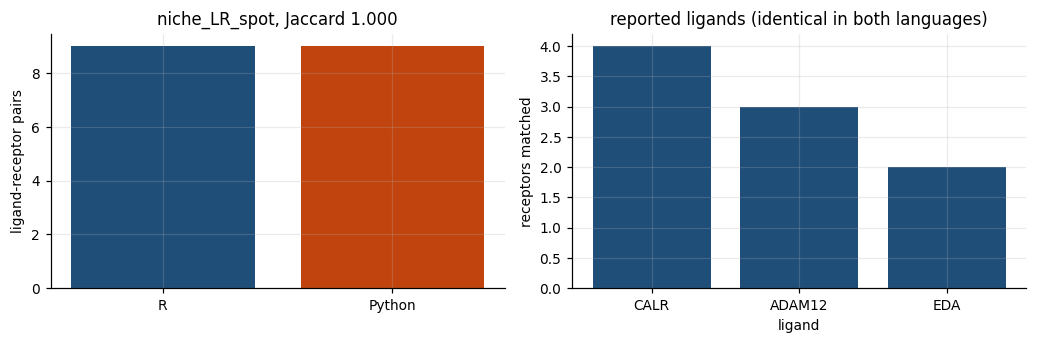

**Sub-verdict — `niche_LR_spot` / ligand-receptor pairs: ✅ Jaccard = 1 (PASS)**

In [30]:
lr_R  = d.csv("ref_niche_LR_spot")
lr_PY = pd.read_csv(os.path.join(REF_DIR, "cand_niche_LR_spot.csv"))
print("R :", lr_R.shape, "  Python:", lr_PY.shape)
display(lr_R); display(lr_PY)
pR  = set(map(tuple, lr_R.iloc[:, :2].astype(str).to_numpy()))
pPY = set(map(tuple, lr_PY.iloc[:, :2].astype(str).to_numpy()))
J = len(pR & pPY) / len(pR | pPY) if (pR | pPY) else 1.0
same = bool((lr_R.iloc[:, 2].astype(str).to_numpy() == lr_PY.iloc[:, 2].astype(str).to_numpy()).all())
print(f"pair Jaccard = {J:.3f}   top-downstream-gene strings identical: {same}")
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.2))
ax[0].bar(["R", "Python"], [len(pR), len(pPY)], color=[C_R, C_PY])
ax[0].set_ylabel("ligand-receptor pairs"); ax[0].set_title(f"niche_LR_spot, Jaccard {J:.3f}")
vc = lr_R["ligand"].value_counts()
ax[1].bar(vc.index, vc.values, color=C_R)
ax[1].set_xlabel("ligand"); ax[1].set_ylabel("receptors matched")
ax[1].set_title("reported ligands (identical in both languages)")
plt.show()
verdict("niche_LR_spot", "ligand-receptor pairs", "ranked", "Jaccard", J, J >= 0.70)

### 2.26 `niche_LR_cell` → `pynichede.niche_LR_cell`

The single-cell-resolution variant: identical ligand scoring, but the confirmation step replaces the Poisson regression with a normal-approximation test of the ligand's mean expression in *pure* cells of the niche type against the `alpha_2` quantile of the reference profile. On this Visium fixture nothing survives, so both languages raise `'no ligand-receptor pairs to report'`.

**Parameters**

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `object` | `obj` | Niche_DE / NicheDEObject | — | — | as `niche_LR_spot`. |
| `ligand_cell` | `ligand_cell` | character / str | — | a cell type name | as `niche_LR_spot`. |
| `receptor_cell` | `receptor_cell` | character / str | — | a cell type name | as `niche_LR_spot`. |
| `ligand_target_matrix` | `ligand_target_matrix` | matrix / DataFrame | — | targets × ligands | as `niche_LR_spot`. |
| `lr_mat` | `lr_mat` | matrix / DataFrame | — | pairs × ≥ 2 | as `niche_LR_spot`. |
| `K` | `K` | integer / int | `25` | `≥ 1` | as `niche_LR_spot`. |
| `M` | `M` | integer / int | `50` | `≥ 1` | as `niche_LR_spot`. |
| `alpha` | `alpha` | numeric / float | `0.05` | `(0, 1)` | as `niche_LR_spot`. |
| `alpha_2` | `alpha_2` | numeric / float | `0.5` | `(0, 1)` | quantile of the reference profile used as the null mean in the single-cell confirmation test. Only present in the `_cell` variant. |
| `truncation_value` | `truncation_value` | numeric / float | `3` | `> 0` | as `niche_LR_spot`. |

**R**

```r
res <- nicheDE::niche_LR_cell(obj, 'myeloid', 'tumor_epithelial',
                              ligand_target_matrix, lr_mat, K = 25, M = 50,
                              alpha = 0.05, alpha_2 = 0.5, truncation_value = 3)
```

**Python**

R  rows reported: None  (None = R raised and wrote no file)
Py rows reported: 0
R error recorded by the driver: no ligand-receptor pairs to report
both report nothing: True


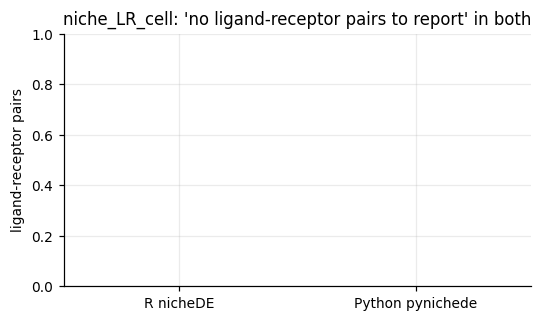

**Sub-verdict — `niche_LR_cell` / empty result / same error: ✅ behaviour match = 1 (PASS)**

In [31]:
def _rows(path):
    if not os.path.exists(path):
        return None
    try:
        return len(pd.read_csv(path))
    except pd.errors.EmptyDataError:
        return 0

n_R  = _rows(os.path.join(REF_DIR, "ref_niche_LR_cell.csv"))
n_PY = _rows(os.path.join(REF_DIR, "cand_niche_LR_cell.csv"))
print("R  rows reported:", n_R, " (None = R raised and wrote no file)")
print("Py rows reported:", n_PY)
print("R error recorded by the driver:", pf.meta["niche_LR_cell_error"])
match = (n_R in (None, 0)) and (n_PY in (None, 0))
print("both report nothing:", match)
fig, ax = plt.subplots(figsize=(5.0, 3.0))
ax.bar(["R nicheDE", "Python pynichede"], [n_R or 0, n_PY or 0], color=[C_R, C_PY])
ax.set_ylim(0, 1); ax.set_ylabel("ligand-receptor pairs")
ax.set_title("niche_LR_cell: 'no ligand-receptor pairs to report' in both")
plt.show()
verdict("niche_LR_cell", "empty result / same error", "classification",
        "behaviour match", 1.0 if match else 0.0, match)

## 3. Aggregate verdict

One row per function × output. `✅` = cleared its gate, `⚠️` = a **documented divergence**
explained in `MATH.md` §3 (poolr's own table accuracy, or the `Rfast::dista` breakage in the
shipped R large-scale effective niche), `❌` = failure.

Function,Output,Class,Metric,Value,Pass
print.Niche_DE,summary string,deterministic,exact string match,1,✅ PASS
CreateLibraryMatrix,library matrix,deterministic,max abs err,0,✅ PASS
CreateLibraryMatrixFromSeurat,library matrix,deterministic,max abs err,0,✅ PASS
CreateNicheDEObject,num_cells / coord / ref_expr / counts,deterministic,max abs err,4.74065e-14,✅ PASS
CreateNicheDEObjectFromSeurat,num_cells / coord,deterministic,max abs err,4.74065e-14,✅ PASS
MergeObjects,coord / num_cells / batch_ID,deterministic,max abs err,4.74065e-14,✅ PASS
Filter_NDE,num_cells / effective_niche,deterministic,max abs err,1.67866e-13,✅ PASS
CalculateEffectiveNiche,effective_niche (all sigma),deterministic,max abs err,2.94875e-13,✅ PASS
CalculateEffectiveNicheLargeScale,effective_niche vs REPAIRED R,deterministic,max abs err,2.94875e-13,✅ PASS
CalculateEffectiveNicheLargeScale,effective_niche vs SHIPPED R,documented divergence,max abs err,16.3913,⚠️ documented


37 comparisons over 26 R functions:  34 pass, 3 documented divergence, 0 fail


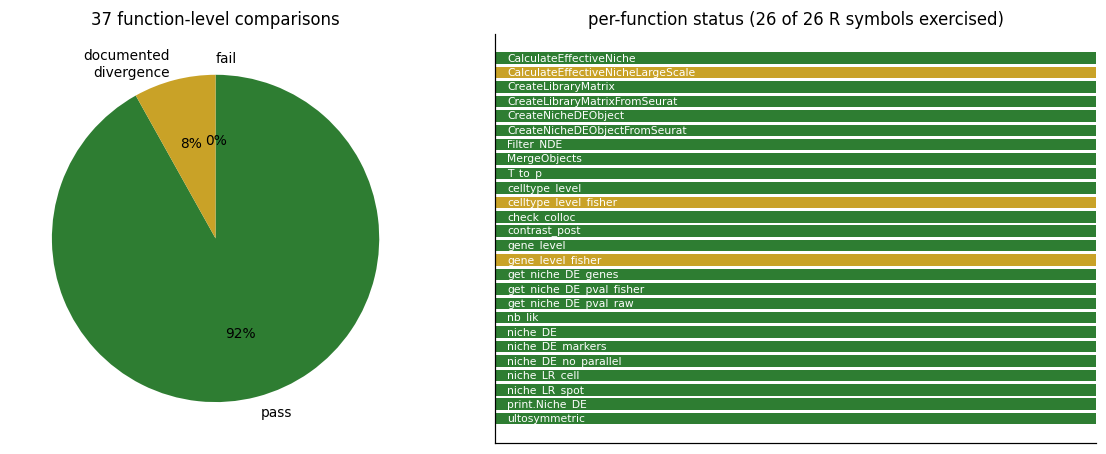


NAMESPACE symbols: 26   covered here: 26   missing: []


## **PASS — all 26 exported R functions reproduced; 34 comparisons cleared their gate and 3 are documented divergences (MATH.md §3)**

In [32]:
V = pd.DataFrame(VERDICTS)
display(V.drop(columns="ok").style.hide(axis="index"))

n_pass = int((V["ok"] == True).sum())
n_doc  = int(V["ok"].isna().sum())
n_fail = int((V["ok"] == False).sum())
print(f"{len(V)} comparisons over {V['Function'].nunique()} R functions:  "
      f"{n_pass} pass, {n_doc} documented divergence, {n_fail} fail")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].pie([n_pass, n_doc, n_fail], labels=["pass", "documented\ndivergence", "fail"],
          colors=["#2e7d32", "#c9a227", C_BAD], autopct="%1.0f%%",
          startangle=90, counterclock=False)
ax[0].set_title(f"{len(V)} function-level comparisons")
by_fn = V.groupby("Function")["ok"].agg(
    lambda s: 2 if (s == False).any() else (1 if s.isna().any() else 0)).sort_index()
colr = {0: "#2e7d32", 1: "#c9a227", 2: C_BAD}
y = np.arange(len(by_fn))[::-1]
ax[1].barh(y, [1] * len(by_fn), color=[colr[v] for v in by_fn.values])
for yi, nm in zip(y, by_fn.index):
    ax[1].text(0.02, yi, nm, va="center", fontsize=7, color="white")
ax[1].set_xlim(0, 1); ax[1].set_xticks([]); ax[1].set_yticks([]); ax[1].grid(False)
ax[1].set_title(f"per-function status ({len(by_fn)} of 26 R symbols exercised)")
plt.show()

covered = set(V["Function"])
ALL_R = ["print.Niche_DE", "CreateLibraryMatrix", "CreateLibraryMatrixFromSeurat",
         "CreateNicheDEObject", "CreateNicheDEObjectFromSeurat", "MergeObjects", "Filter_NDE",
         "CalculateEffectiveNiche", "CalculateEffectiveNicheLargeScale", "niche_DE",
         "niche_DE_no_parallel", "get_niche_DE_pval_fisher", "get_niche_DE_pval_raw",
         "T_to_p", "ultosymmetric", "gene_level", "celltype_level", "gene_level_fisher",
         "celltype_level_fisher", "contrast_post", "check_colloc", "nb_lik",
         "get_niche_DE_genes", "niche_DE_markers", "niche_LR_spot", "niche_LR_cell"]
missing = [f for f in ALL_R if f not in covered]
print(f"\nNAMESPACE symbols: {len(ALL_R)}   covered here: {len(covered)}   missing: {missing}")
if n_fail == 0 and not missing:
    display(Markdown(f"## **PASS — all {len(ALL_R)} exported R functions reproduced; "
                     f"{n_pass} comparisons cleared their gate and {n_doc} are "
                     f"documented divergences (MATH.md \u00a73)**"))
else:
    display(Markdown(f"## **FAIL — {n_fail} failing comparison(s), {len(missing)} uncovered symbol(s)**"))

## 4. Porting cheat-sheet

| you wrote in R | write in Python |
|---|---|
| `library(nicheDE)` | `import pynichede as nde` |
| `CreateLibraryMatrix(data, cell_type)` | `nde.create_library_matrix(data, cell_type)` |
| `CreateLibraryMatrixFromSeurat(so, "RNA")` | `nde.create_library_matrix_from_anndata(adata, "cell_type")` |
| `CreateNicheDEObject(cts, xy, L, P, sigma)` | `nde.create_nichede_object(cts, xy, L, P, sigma=sigma)` |
| `CreateNicheDEObjectFromSeurat(so, "Spatial", L, P, sigma)` | `nde.create_nichede_object_from_anndata(adata, L, P, sigma=sigma)` |
| `MergeObjects(list(o1, o2))` | `nde.merge_objects([o1, o2])` |
| `Filter_NDE(obj, keep)` | `nde.filter_nde(obj, keep)` |
| `CalculateEffectiveNiche(obj, 0.05)` | `nde.calculate_effective_niche(obj, cutoff=0.05)` |
| `CalculateEffectiveNicheLargeScale(obj, 1000, 0.05, TRUE)` | `nde.calculate_effective_niche_large_scale(obj, batch_size=1000, cutoff=0.05, standardize=True)` |
| `niche_DE(obj, 16, "", 150, 10, 0.8, T, T, T, F, 1)` | `nde.niche_DE(obj, num_cores=16, C=150, M=10, gamma=0.8, Int=True, batch=True, self_EN=False)` |
| `niche_DE_no_parallel(obj, ...)` | `nde.niche_DE_no_parallel(obj, ...)` (= `num_cores=1`) |
| `get_niche_DE_pval_fisher(obj, TRUE)` | `nde.get_niche_DE_pval_fisher(obj, pos=True)` |
| `get_niche_DE_pval_raw(obj, TRUE)` | `nde.get_niche_DE_pval_raw(obj, pos=True)` — or `NicheDE(obj).pval_raw()` to avoid mutating |
| `get_niche_DE_genes(obj, "I", idx, nch, T, .05)` | `nde.get_niche_DE_genes(obj, "I", index=idx, niche=nch, positive=True, alpha=0.05)` |
| `niche_DE_markers(obj, i, n1, n2, .05)` | `nde.niche_DE_markers(obj, i, n1, n2, alpha=0.05)` |
| `niche_LR_spot(obj, lc, rc, ltm, lr, 25, 50, .05, 3)` | `nde.niche_LR_spot(obj, lc, rc, ltm, lr, K=25, M=50, alpha=0.05, truncation_value=3)` |
| `niche_LR_cell(..., alpha_2 = 0.5, ...)` | `nde.niche_LR_cell(..., alpha_2=0.5, ...)` |
| `check_colloc(obj, 4, 6)` **1-based** | `nde.check_colloc(obj, 3, 5)` **0-based** — or `NicheDE(obj).check_colloc("tumor_epithelial", "myeloid")` |
| `contrast_post(b, V, n, 4, c(6, 7))` **1-based** | `nde.contrast_post(b, V, n, 3, (5, 6), n_type=7)` **0-based** |
| `T_to_p(T, "positive")` | `nde.T_to_p(T, "positive")` |
| `gene_level(p, w)` / `celltype_level(p, w)` | `nde.gene_level(p, w)` / `nde.celltype_level(p, w)` |
| `gene_level_fisher(p, V, T)` / `celltype_level_fisher(p, V)` | `nde.gene_level_fisher(p, V, beta_cov=True)` / `nde.celltype_level_fisher(p, V)` |
| `ultosymmetric(m)` / `nb_lik(x, mu, d)` | `nde.ultosymmetric(m)` / `nde.nb_lik(x, mu, d)` |
| `print(obj)` | `print(obj)` / `repr(obj)` |
| `poolr::mvnconv(R, 1, "m2lp")` | `nde.mvnconv(R, side=1, target="m2lp")` — **new in Python**, poolr re-derived clean-room |
| `poolr::fisher(p, R=cv, adjust="generalized")$p` | `nde.fisher_generalized(p, cv)` — **new in Python**, same reason |

Further reading: [`MATH.md`](../MATH.md) (derivations and the divergence table),
[`AUDIT.md`](../AUDIT.md) (R function coverage),
[`compare_R_vs_Python.ipynb`](compare_R_vs_Python.ipynb) (pipeline parity),
[`tutorial_liver_met_visium.ipynb`](tutorial_liver_met_visium.ipynb) (Python walkthrough).